In [1]:
import pandas as pd, numpy as np             # Data manipulation
from matplotlib import pyplot as plt         # Graphing
import seaborn as sns                        # Graphing
from scipy import stats
import warnings


In [2]:
df = pd.read_excel('Houses for rent in Madrid.xlsx')

In [3]:
df.shape

(2089, 15)

In [4]:
df.isna().sum()

Id                 0
District           0
Address            0
Number          1342
Area               4
Rent               0
Bedrooms          89
Sq.Mt              0
Floor            141
Outer            162
Elevator         133
Penthouse          0
Cottage            0
Duplex             0
Semidetached       0
dtype: int64

In [5]:
df.describe()

,Id,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
count,2089.000000,2089.000000,2000.000000,2089.000000,1948.000000,1927.000000,1956.000000,2089.000000,2089.000000,2089.000000,2089.000000
mean,1094.026807,1932.249402,2.483000,128.919579,25.662731,0.867151,0.880879,0.080900,0.042125,0.030637,0.013404
std,630.612544,1495.474485,1.305206,115.745014,975.065350,0.339500,0.324013,0.272747,0.200923,0.172373,0.115023
min,1.000000,450.000000,0.000000,15.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,550.000000,950.000000,2.000000,65.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1094.000000,1400.000000,2.000000,90.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1636.000000,2500.000000,3.000000,147.000000,5.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2188.000000,16000.000000,8.000000,1250.000000,43039.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2089 non-null   int64  
 1   District      2089 non-null   object 
 2   Address       2089 non-null   object 
 3   Number        747 non-null    object 
 4   Area          2085 non-null   object 
 5   Rent          2089 non-null   int64  
 6   Bedrooms      2000 non-null   float64
 7   Sq.Mt         2089 non-null   int64  
 8   Floor         1948 non-null   float64
 9   Outer         1927 non-null   float64
 10  Elevator      1956 non-null   float64
 11  Penthouse     2089 non-null   int64  
 12  Cottage       2089 non-null   int64  
 13  Duplex        2089 non-null   int64  
 14  Semidetached  2089 non-null   int64  
dtypes: float64(4), int64(7), object(4)
memory usage: 244.9+ KB


1) Data Cleaning

In [7]:
df.isnull().sum()

Id                 0
District           0
Address            0
Number          1342
Area               4
Rent               0
Bedrooms          89
Sq.Mt              0
Floor            141
Outer            162
Elevator         133
Penthouse          0
Cottage            0
Duplex             0
Semidetached       0
dtype: int64

1.1) Delete useless columns

In [8]:
df = df.drop(columns=['Id', 'Number'])

In [9]:
df

,District,Address,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,Ciudad Lineal,Piso en Quintana,Quintana,1300,2.0,72,3.0,1.0,1.0,0,0,0,0
1,Ciudad Lineal,Piso en calle de Arturo Soria,Costillares,3000,5.0,260,2.0,1.0,1.0,0,0,0,0
2,Ciudad Lineal,Piso en calle de Vicente Muzas,Colina,1300,2.0,100,3.0,1.0,1.0,0,0,0,0
3,Ciudad Lineal,Piso en calle Badajoz,San Pascual,1600,3.0,120,4.0,1.0,1.0,0,0,0,0
4,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,Ventas,800,2.0,60,3.0,1.0,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2084,Vicálvaro,Piso en calle Villajoyosa,Los Rosales,1100,3.0,70,3.0,1.0,1.0,0,0,0,0
2085,Vicálvaro,Piso en Los Ángeles,Los Ángeles,670,2.0,61,NaN,0.0,0.0,0,0,0,0
2086,Vicálvaro,Piso en San Andrés,San Andrés,450,1.0,45,NaN,0.0,0.0,0,0,0,0
2087,Vicálvaro,Piso en calle del Doctor MartÃ­n ArÃ©valo,San Andrés,750,2.0,92,0.0,1.0,1.0,0,0,0,0


1.1) Bedroom NaNs: The studio problem (Estudio usually have 0 bedrooms)

In [10]:
# Step 1: Create a mask that checks if the Address contains the word 'Estudio' (ignoring upper/lower case)
is_studio = df['Address'].str.contains('Estudio', case=False, na=False)

# Step 2: Apply the 0 ONLY to rows that are studios AND have a missing bedroom value
df.loc[is_studio & df['Bedrooms'].isna(), 'Bedrooms'] = 0

In [11]:
df.isnull().sum()

District          0
Address           0
Area              4
Rent              0
Bedrooms          7
Sq.Mt             0
Floor           141
Outer           162
Elevator        133
Penthouse         0
Cottage           0
Duplex            0
Semidetached      0
dtype: int64

1.2) Bedroom NaNs: The rest of the missing value are complicated to impute, the decision will hence be to delete those rows, representing 0,3% of our dataset

In [12]:
# Drop the rows where 'Bedrooms' is NaN
df = df.dropna(subset=['Bedrooms'])

In [13]:
df.shape

(2082, 13)

1.3) Area NaNs: We can hard code which area they are located in looking at the address

In [14]:
df[df['Area'].isna() == True]

,District,Address,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
1862,Tetuán,Piso en Bellas Vistas,NaN,1000,2.0,54,4.0,1.0,0.0,0,0,0,0
1867,Tetuán,Piso en Ventilla-Almenara,NaN,3500,4.0,190,5.0,1.0,1.0,0,0,0,0
1868,Tetuán,Piso en Cuzco-Castillejos,NaN,1250,2.0,77,5.0,1.0,1.0,0,0,0,0
1869,Tetuán,Piso en Cuatro Caminos,NaN,1750,1.0,74,15.0,1.0,1.0,0,0,0,0


In [15]:
area_fixes = {
    'Piso en Bellas Vistas': 'Bellas Vistas',
    'Piso en Ventilla-Almenara': 'Ventilla-Almenara',
    'Piso en Cuzco-Castillejos': 'Cuzco-Castillejos',
    'Piso en Cuatro Caminos': 'Cuatro Caminos'
}

# Step 2: Loop through the dictionary and hardcode the missing Areas
for address_text, correct_area in area_fixes.items():
    # Create a mask to find the exact row that has a missing Area AND matches the address
    mask = df['Area'].isna() & (df['Address'] == address_text)
    
    # Apply the correct Area to that specific row
    df.loc[mask, 'Area'] = correct_area

In [16]:
df.isnull().sum()

District          0
Address           0
Area              0
Rent              0
Bedrooms          0
Sq.Mt             0
Floor           141
Outer           162
Elevator        133
Penthouse         0
Cottage           0
Duplex            0
Semidetached      0
dtype: int64

1.4) Managing the Cottage: Because they are standalone houses, the real estate agents left Floor, Elevator, and Outer blank.
Floor: A house is on the ground level (0).
Elevator: A house doesn't have a shared building elevator (0).
Outer: A house is exposed to the street on its sides (1).

In [17]:
# Create a mask for properties that are cottages/chalets
is_cottage = df['Cottage'] == 1

# Apply logical fills ONLY to the cottages
df.loc[is_cottage, 'Floor'] = df.loc[is_cottage, 'Floor'].fillna(0)
df.loc[is_cottage, 'Elevator'] = df.loc[is_cottage, 'Elevator'].fillna(0)
df.loc[is_cottage, 'Outer'] = df.loc[is_cottage, 'Outer'].fillna(1)

In [18]:
df.isnull().sum()

District         0
Address          0
Area             0
Rent             0
Bedrooms         0
Sq.Mt            0
Floor           57
Outer           77
Elevator        48
Penthouse        0
Cottage          0
Duplex           0
Semidetached     0
dtype: int64

1.5) Last imputations, explanations:

Elevator and Outer (Exterior) Features: We hypothesized that a property’s structural amenities are heavily dictated by its location and its socio-economic target market. We first stratified the dataset into three equal pricing tiers (Budget, Average, and Luxury). Missing 'Elevator' and 'Outer' values were then imputed using the most frequent occurrence (the mode) of properties located in the same District and within the same pricing tier. This ensured, for example, that a missing elevator in a "Luxury" listing in Salamanca was treated differently than a "Budget" listing in Centro.

Floor Number: Based on the architectural reality of Madrid, building height is strongly correlated with the presence of an elevator. To impute missing floor numbers, we grouped properties by their District and their Elevator status (Yes/No). We then applied the median floor number of that specific subgroup. This logically prevented the model from assigning high floor numbers (e.g., 5th or 6th floor) to walk-up apartments without elevators.

In [19]:
# --- Deep Inference Imputation for Missing Values ---

# --- Leakage-free imputation (NO Rent used) ---

import numpy as np
import pandas as pd

def group_mode_fill(df, col, by):
    """
    Fill NaNs in df[col] with the mode within each group 'by'.
    If a group has no mode (all NaN), leave as NaN for later fallback.
    """
    df[col] = df.groupby(by)[col].transform(
        lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
    )
    return df

# 0) Keep your cottage logic (you already did it, repeating here for safety)
is_cottage = df['Cottage'] == 1
df.loc[is_cottage, 'Floor']    = df.loc[is_cottage, 'Floor'].fillna(0)
df.loc[is_cottage, 'Elevator'] = df.loc[is_cottage, 'Elevator'].fillna(0)
df.loc[is_cottage, 'Outer']    = df.loc[is_cottage, 'Outer'].fillna(1)

# 1) FLOOR (numeric) — impute FIRST using only geography/property type
#    (breaks the circular dependency "Floor <-> Elevator")
df['Floor'] = df.groupby(['District', 'Cottage'])['Floor'].transform(lambda x: x.fillna(x.median()))
df['Floor'] = df['Floor'].fillna(df['Floor'].median())

# 2) Create a coarse floor bin to help impute Elevator/Outer (still no Rent)
df['Floor_bin'] = pd.cut(
    df['Floor'],
    bins=[-np.inf, 0, 2, 5, np.inf],
    labels=['<=0', '1-2', '3-5', '6+']
)

# 3) ELEVATOR (binary)
#    - deterministic rule: no elevator for floor <= 0 (and cottages already handled)
df.loc[df['Floor'] <= 0, 'Elevator'] = df.loc[df['Floor'] <= 0, 'Elevator'].fillna(0)

#    - then hierarchical mode fills (more specific -> less specific)
df = group_mode_fill(df, 'Elevator', ['District', 'Floor_bin'])
df = group_mode_fill(df, 'Elevator', ['District'])

#    - final fallback (global)
df['Elevator'] = df['Elevator'].fillna(0).astype(int)

# 4) OUTER (binary)
#    (cottages already set to 1 above)
df = group_mode_fill(df, 'Outer', ['Area'])      # more granular
df = group_mode_fill(df, 'Outer', ['District'])  # fallback
df['Outer'] = df['Outer'].fillna(1).astype(int)  # global fallback

# 5) Optional refinement: now that Elevator is filled, re-impute remaining Floor gaps by (District, Elevator)
df['Floor'] = df.groupby(['District', 'Elevator'])['Floor'].transform(lambda x: x.fillna(x.median()))
df['Floor'] = df['Floor'].fillna(df['Floor'].median())

# 6) Clean up helper column
df = df.drop(columns=['Floor_bin'])

# Check
print(df[['Floor', 'Outer', 'Elevator']].isna().sum())

Floor       0
Outer       0
Elevator    0
dtype: int64


C:\Users\sacha\AppData\Local\Temp\ipykernel_20600\3887354184.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Floor'] = df.groupby(['District', 'Cottage'])['Floor'].transform(lambda x: x.fillna(x.median()))
C:\Users\sacha\AppData\Local\Temp\ipykernel_20600\3887354184.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Floor'] = df['Floor'].fillna(df['Floor'].median())
C:\Users\sacha\AppData\Local\Temp\ipykernel_20600\3887354184.py:30: SettingWithCopyWarning: 
A value is trying to be set on a co

In [20]:
df.isnull().sum()

District        0
Address         0
Area            0
Rent            0
Bedrooms        0
Sq.Mt           0
Floor           0
Outer           0
Elevator        0
Penthouse       0
Cottage         0
Duplex          0
Semidetached    0
dtype: int64

2) Feature Engineering

2.1) FE1: The Spaciousness Index:

The Concept: A 100 $m^2$ apartment with 1 bedroom is a spacious luxury pad. A 100 $m^2$ apartment with 4 bedrooms is likely a cramped student flat. Raw square meters alone don't tell the model how "crowded" a flat feels.

The Engineering: Create a new variable called SqMt_per_Bedroom.Calculation: Sq.Mt / Bedrooms (For studios where Bedrooms=0, you can divide by 1 to represent the single living space).

Why it's great: This is a fantastic variable for your Phase 1 Segmentation. It will perfectly separate high-end luxury properties from high-density budget properties.

In [21]:
# Create the Spaciousness Index (Sq. Meters per Bedroom)
# We use .replace(0, 1) to ensure studios are divided by 1, avoiding a "Division by Zero" error.
df['SqMt_per_Bedroom'] = df['Sq.Mt'] / df['Bedrooms'].replace(0, 1)

2.2) FE2: Logarithmic Transformations (Data Transformation)

The Concept: In your class materials, transformations are repeatedly mentioned as a key preprocessing step. For Option A (Linear Regression), the model assumes your data follows a normal distribution (a bell curve). However, real estate variables like Rent and Sq.Mt are almost always heavily "right-skewed" (most flats are average price, but a few mega-mansions stretch the data far to the right).

The Engineering: Create Log_Rent and Log_SqMt using the natural logarithm (np.log()).

Why it's great: Running your linear regression on the log of the rent rather than the raw rent significantly improves the model's accuracy and helps fix "heteroscedasticity" (a statistical error that professors always look for!).

In [22]:
import numpy as np

# Create Logarithmic versions of heavily skewed continuous variables
df['Log_Rent'] = np.log(df['Rent'])
df['Log_SqMt'] = np.log(df['Sq.Mt'])

THE FOLLOWING WILL BE DONE FOR THE LINEAR REGRESSION PART

2.3) FE3: Categorical Encoding (Dummy Variables)

The Concept: Linear regression models cannot read text. They only understand numbers. Your District column (e.g., "Centro", "Tetuán", "Retiro") contains massive predictive power, but it's currently text.

The Engineering: You must use One-Hot Encoding (creating "Dummy Variables"). This turns the District column into 20 distinct columns like District_Centro, District_Retiro, containing 1s and 0s.

Why it's great: This is absolutely mandatory for Phase 2. A linear regression model needs these 1s and 0s to calculate exactly how much extra rent a property can command just by being located in the "Salamanca" district versus the "Vallecas" district.

Baseline District is: Arganzuela (Because 'A' comes first alphabetically),
Baseline Area is: 12 de Octubre-Orcasur (Because numbers come before letters)

Crucial Reminder: These dummies will only be used in the Linear regression part of the study, not the segmentation

2.4) FE4: The "Value" Metric (Price per Square Meter)

This is the holy grail of real estate metrics. A 1,500€ rent might be cheap for a 150m2 family home, but it is astronomically expensive for a 30m2 studio. This variable normalizes the price so you can find the "Luxury/Premium" properties regardless of their actual size.

Crucial Reminder: You MUST drop this column before running your Phase 2 Linear Regression to avoid data leakage!

In [23]:
# 1. Price per Square Meter
df['Price_per_sqm'] = df['Rent'] / df['Sq.Mt']

2.5) FE5: Distance To Center:

This metric calculates the distance of each area to Puerta Del Sol (proxi for center)

In [24]:
import pandas as pd
import numpy as np
import time
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

# 1. Define our center point (Puerta del Sol, Madrid)
# These are the exact latitude and longitude coordinates for Puerta del Sol
sol_coords = (40.416729, -3.703339) 

# 2. Initialize the map searcher (Geocoder)
# Nominatim requires a unique 'user_agent' name so they know who is using their free server
geolocator = Nominatim(user_agent="madrid_real_estate_student_project")

# 3. Get a list of all unique Areas in your dataset
unique_areas = df['Area'].dropna().unique()
area_coordinates = {}

print(f"Starting to find coordinates for {len(unique_areas)} areas. This might take a minute...")

# 4. Loop through each Area and ask the map for its coordinates
for area in unique_areas:
    try:
        # We add "Madrid, Spain" so the search engine knows exactly where to look
        search_query = f"{area}, Madrid, Spain"
        location = geolocator.geocode(search_query, timeout=10)
        
        if location:
            # If found, save the Lat/Lon
            area_coordinates[area] = (location.latitude, location.longitude)
        else:
            # If the map doesn't recognize the specific real estate name, mark as NaN
            area_coordinates[area] = (np.nan, np.nan)
            
        # VERY IMPORTANT: We must pause for 1 second between searches 
        # so OpenStreetMap doesn't block us for spamming their free server!
        time.sleep(1) 
        
    except Exception as e:
        area_coordinates[area] = (np.nan, np.nan)

# 5. Map the coordinates back to our main dataset
df['Area_Coords'] = df['Area'].map(area_coordinates)

# 6. Calculate the distance from each Area to Puerta del Sol (in Kilometers)
def calculate_distance(coords):
    # If the geocoder failed to find the area, return NaN
    if pd.isna(coords[0]): 
        return np.nan
    # Otherwise, calculate the distance in kilometers
    return geodesic(coords, sol_coords).kilometers

df['Distance_to_Center_km'] = df['Area_Coords'].apply(calculate_distance)

# 7. Clean up: We don't need the raw coordinates column anymore
df = df.drop(columns=['Area_Coords'])

print("\nDistance calculation complete!")
print(df[['Area', 'Distance_to_Center_km']].head(10))

Starting to find coordinates for 139 areas. This might take a minute...

Distance calculation complete!
                Area  Distance_to_Center_km
0           Quintana               5.214658
1        Costillares               7.219175
2             Colina               5.866195
3        San Pascual               5.121022
4             Ventas               3.733656
5  San Juan Bautista               5.491001
6         Concepción               5.147807
7        Costillares               7.219175
8         Concepción               5.147807
9  San Juan Bautista               5.491001


In [25]:
df[df['Distance_to_Center_km'].isna() == True]

,District,Address,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,SqMt_per_Bedroom,Log_Rent,Log_SqMt,Price_per_sqm,Distance_to_Center_km
589,Retiro,Piso en calle de los Reyes Magos,Niño JesÁºs,1100,1.0,65,1.0,0,1,0,0,0,0,65.000000,7.003065,4.174387,16.923077,NaN
591,Retiro,Piso en Niño Jesús,Niño JesÁºs,3800,3.0,160,6.0,1,1,0,0,0,0,53.333333,8.242756,5.075174,23.750000,NaN
596,Retiro,Piso en calle del alcalde sáinz de baranda,Niño JesÁºs,1500,3.0,95,1.0,1,1,0,0,0,0,31.666667,7.313220,4.553877,15.789474,NaN
599,Retiro,Piso en Niño Jesús,Niño JesÁºs,3000,4.0,199,9.0,1,1,0,0,0,0,49.750000,8.006368,5.293305,15.075377,NaN
603,Retiro,Piso en Niño Jesús,Niño JesÁºs,1500,2.0,125,8.0,1,1,0,0,0,0,62.500000,7.313220,4.828314,12.000000,NaN
609,Retiro,Piso en Niño Jesús,Niño JesÁºs,4000,4.0,256,2.0,1,1,0,0,0,0,64.000000,8.294050,5.545177,15.625000,NaN
620,Retiro,Piso en avenida de Menéndez Pelayo,Niño JesÁºs,2430,2.0,73,2.0,1,1,0,0,0,0,36.500000,7.795647,4.290459,33.287671,NaN
644,Retiro,Piso en avenida de Menéndez Pelayo,Niño JesÁºs,3250,2.0,160,9.0,1,1,0,0,0,0,80.000000,8.086410,5.075174,20.312500,NaN
661,Retiro,Casa o chalet independiente en Niño Jesús,Niño JesÁºs,5950,4.0,235,0.0,1,0,0,1,0,0,58.750000,8.691146,5.459586,25.319149,NaN
664,Retiro,Piso en Niño Jesús,Niño JesÁºs,2500,4.0,165,6.0,1,1,0,0,0,0,41.250000,7.824046,5.105945,15.151515,NaN


cleaning the nulls from this new column (mainly text issues)

In [26]:
import time
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

# 1. Dictionary of the exact encoding errors and messy text you found
area_corrections = {
    'Niño JesÁºs': 'Niño Jesús',
    'chalet independiente en Nueva España': 'Nueva España',
    'en Nuevos Ministerios-Ríos Rosas': 'Ríos Rosas', 
    'HellÁ­n': 'Hellín',
    'ZofÁ­o': 'Zofío',
    'San FermÁ­n': 'San Fermín',
    'Valdebernardo - Valderribas': 'Valdebernardo' 
}

# 2. Apply the text corrections to your Area column
df['Area'] = df['Area'].replace(area_corrections)

# 3. Setup the map searcher and the coordinates for Puerta del Sol
sol_coords = (40.416729, -3.703339) 
geolocator = Nominatim(user_agent="madrid_real_estate_student_project")

print("Fetching distances for the corrected areas...")

# 4. Loop ONLY through the corrected areas so you don't have to wait for the whole dataset
for bad_name, good_name in area_corrections.items():
    try:
        # Search for the corrected name on the map
        search_query = f"{good_name}, Madrid, Spain"
        location = geolocator.geocode(search_query, timeout=10)
        
        if location:
            # Calculate distance
            dist = geodesic((location.latitude, location.longitude), sol_coords).kilometers
            
            # Update the specific rows in our dataframe that match the good_name
            df.loc[df['Area'] == good_name, 'Distance_to_Center_km'] = dist
            print(f"Successfully updated: {good_name}")
            
        time.sleep(1) # Pause 1 second to avoid server block
    except Exception as e:
        print(f"Failed to fetch {good_name}")

# 5. Final check to see how many missing values are left
print(f"Missing distances after text fix: {df['Distance_to_Center_km'].isna().sum()}")

Fetching distances for the corrected areas...
Successfully updated: Niño Jesús
Successfully updated: Nueva España
Successfully updated: Ríos Rosas
Successfully updated: Hellín
Successfully updated: Zofío
Successfully updated: San Fermín
Successfully updated: Valdebernardo
Missing distances after text fix: 0


In [27]:
df.isnull().sum()

District                 0
Address                  0
Area                     0
Rent                     0
Bedrooms                 0
Sq.Mt                    0
Floor                    0
Outer                    0
Elevator                 0
Penthouse                0
Cottage                  0
Duplex                   0
Semidetached             0
SqMt_per_Bedroom         0
Log_Rent                 0
Log_SqMt                 0
Price_per_sqm            0
Distance_to_Center_km    0
dtype: int64

Final Step before Segmentation: Checking outliers

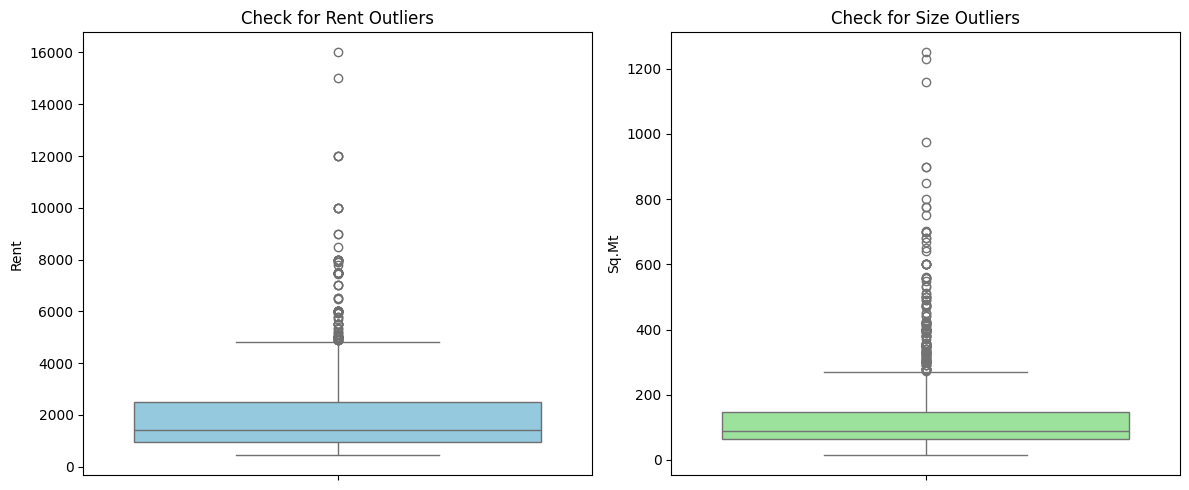

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Boxplot for Rent
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Rent'], color='skyblue')
plt.title('Check for Rent Outliers')

# Boxplot for Sq.Mt
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Sq.Mt'], color='lightgreen')
plt.title('Check for Size Outliers')

plt.tight_layout()
plt.show()

We realise that indeed, there are a few outliers in those 2 variables (columns). However, it is potentially interesting to first run the segmentation with those outliers, and then without them, to see the actual difference and how they impact the model.

PHASE 1: SEGMENTATION

STEP 1: SELECTING THE CLUSTERING VARIABLES VS THE PROFILING VARIABLES

1. The Clustering Variables (The "Math")
These 4 variables will be fed into the K-Means algorithm.

K-Means calculates physical, straight-line distance (Euclidean distance) between properties. Therefore, these must be purely continuous, numeric metrics. We selected exactly one variable for each core dimension of real estate so that no single concept (like "money") gets too many "votes" and overpowers the others:

Rent (The Cost Dimension): Absolute monthly price.

Sq.Mt (The Size Dimension): Absolute physical space.

Distance_to_Center_km (The Location Dimension): By using this engineered variable instead of the text District, we give the algorithm a clean, mathematical way to measure how central or suburban a property is.

Number of Bedrooms (The Layout/Density Dimension): This tells the algorithm if the apartment is a spacious luxury pad or a cramped student flat.

Note: We will standardize (Z-score) these 4 variables before running the algorithm so that Rent (in the thousands) doesn't mathematically swallow Distance (in decimals).

2. The Profiling Variables (The "Story")
These variables will NOT go into the K-Means math. Once the algorithm assigns every flat a "Cluster Number," we will calculate the averages and percentages of these variables to explain who lives in these segments and what the buildings look like.

Price_per_sqm (The Value Label): We deliberately excluded this from the clustering math to avoid "Redundancy." If we included Rent, Sq.Mt, and Price_per_sqm, we would give the financial/size dimensions 3 times more weight than location! We keep it here to easily label the clusters later (e.g., identifying the "Premium" segment).

District and Area (The Geography): Text variables completely break Euclidean math. We keep them here to see the geographic concentration of our clusters (e.g., "Cluster 1 is 80% located in Centro").

Bedrooms and Floor (The Demographics): Discrete integers. They help us tell the story (e.g., "This cluster averages 4 bedrooms and is mostly ground floor, indicating suburban families").

Elevator, Outer, Penthouse, Cottage, etc. (The Structural Features): Binary variables (0 or 1) create weird, unnatural geometric spaces in K-Means. We keep them out of the math and use them here to define the architectural quality of the segment.

This exact setup avoids the "Curse of Dimensionality," prevents feature overweighting, and keeps your math perfectly clean.

1.5) Last imputations, explanations (Leakage-free):

Important note on leakage: Because Rent is a key outcome variable later in the project, we deliberately avoided using Rent (or any Rent-derived tier such as “Budget/Average/Luxury”) to impute missing values in predictors like Elevator or Outer. Instead, we used only non-target information (geography, property type, and building structure) to ensure the dataset remains valid for later predictive modeling.

Cottage rule (domain logic): Cottages are ground-level properties by definition, so we set:

Floor = 0, Elevator = 0, and Outer = 1 whenever Cottage = 1.

Floor imputation (done first to avoid circularity):
Missing Floor values were imputed using the median floor within similar properties based on (District, Cottage). If a subgroup had insufficient information, we used the overall dataset median as a fallback. This provides a stable, non-leaky estimate of typical building height by area and property type.

Elevator imputation (based on building structure + location):
Elevator availability is strongly related to building height. We:

applied a deterministic rule: if Floor <= 0, then Elevator = 0 (walk-up/ground cases),

then imputed remaining missing Elevator values using the mode within (District, Floor_bin) (where Floor is binned into broad categories),

and used District mode and finally a global fallback as needed.

Outer imputation (based on geography):
Exterior-facing properties are driven more by neighborhood/building stock than by price. We imputed missing Outer values using the mode within Area, and if missing, within District, with a final global fallback.

Optional refinement: After imputing Elevator, we optionally refined remaining Floor gaps using the median within (District, Elevator), since elevator presence provides additional building-structure information.

STEP 2: STANDARDIZE THE CLUSTERING VARIABLES

In [29]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Our perfected 4 continuous clustering variables
cluster_features = [
    'Rent', 
    'Sq.Mt', 
    'Distance_to_Center_km',
    'Bedrooms'
]

# Create our clustering dataframe and drop any remaining NaNs
df_cluster = df.dropna(subset=cluster_features).copy()

# 2. SCALE THE DATA (Mandatory for K-Means)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster[cluster_features])

print(scaled_data)

[[-0.4237698  -0.49363731  0.32891055 -0.28177327]
 [ 0.71188394  1.12950754  1.02340867  1.91268542]
 [-0.4237698  -0.25189233  0.55464637 -0.28177327]
 ...
 [-0.99159667 -0.72674853  1.27024065 -1.0132595 ]
 [-0.79118719 -0.32096232  1.27024065 -0.28177327]
 [-0.69098244  0.61148259  1.27024065 -1.74474574]]


STEP 3: COMPUTING THE ELBOW CURVE

Calculating the Elbow Curve. This will take just a few seconds...


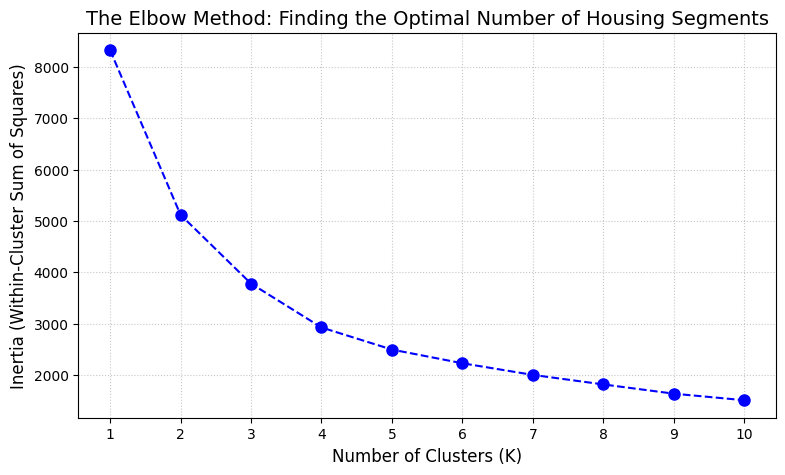

In [30]:
inertia = []
K_range = range(1, 11)

print("Calculating the Elbow Curve. This will take just a few seconds...")

for k in K_range:
    # random_state=42 ensures you get the exact same results every time you run it
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# 4. PLOT THE RESULTS
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b', markersize=8)
plt.title('The Elbow Method: Finding the Optimal Number of Housing Segments', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [31]:
print([int(i) for i in inertia])

[8328, 5120, 3780, 2925, 2495, 2228, 2001, 1815, 1635, 1508]


The conclusion of the Elbow Method is that we will use a k=4 for our k-means analysis. (Important note for report, explain why you used k-means).

STEP 4: RUNNING THE K-MEANS SEGMENTATION 1.0

In [32]:
from sklearn.cluster import KMeans

# 1. Initialize the K-Means model with K=4
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# 2. Fit the model and predict the cluster for each property
# We use the 'scaled_data' from our previous step
cluster_labels = final_kmeans.fit_predict(scaled_data)

# 3. Attach these new labels directly to your dataframe
# We use df_cluster.index to safely match the labels to the exact rows we clustered
df.loc[df_cluster.index, 'Cluster'] = cluster_labels

# 4. Check the >5% Rule!
print("Number of properties in each cluster:")
print(df['Cluster'].value_counts())
print("\nPercentage of dataset:")
print((df['Cluster'].value_counts() / len(df_cluster)) * 100)

Number of properties in each cluster:
Cluster
0.0    1091
2.0     495
1.0     425
3.0      71
Name: count, dtype: int64

Percentage of dataset:
Cluster
0.0    52.401537
2.0    23.775216
1.0    20.413064
3.0     3.410183
Name: count, dtype: float64


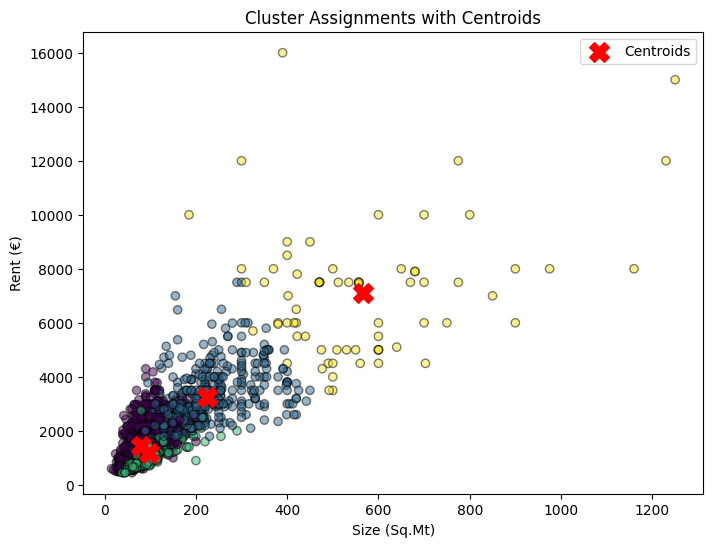

In [33]:
# Create a scatter plot of Rent vs Size
plt.figure(figsize=(8, 6))
plt.scatter(df['Sq.Mt'], df['Rent'], c=df['Cluster'], cmap='viridis', alpha=0.5, edgecolor='k')

# Get the un-scaled centroids by inverse transforming them
centroids = scaler.inverse_transform(final_kmeans.cluster_centers_)

# Plot the centroids on top (assuming Sq.Mt is index 1 and Rent is index 0 in your cluster_features)
plt.scatter(centroids[:, 1], centroids[:, 0], color='red', marker='X', s=200, label='Centroids')
plt.title("Cluster Assignments with Centroids")
plt.xlabel("Size (Sq.Mt)")
plt.ylabel("Rent (€)")
plt.legend()
plt.show()

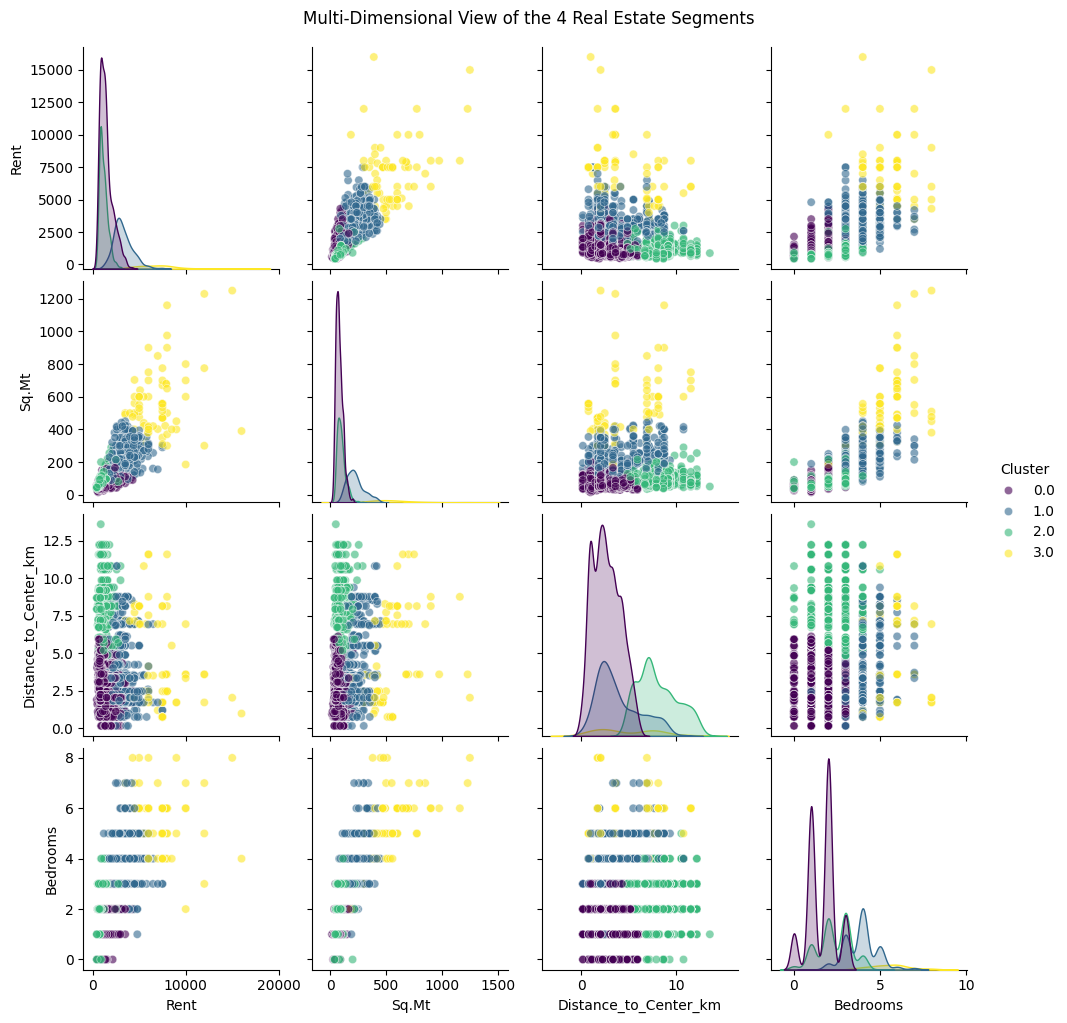

In [34]:
import seaborn as sns

# Plot all 4 clustering variables against each other, colored by Cluster
sns.pairplot(df.loc[df_cluster.index], vars=cluster_features, hue='Cluster', palette='viridis', plot_kws={'alpha':0.6})
plt.suptitle("Multi-Dimensional View of the 4 Real Estate Segments", y=1.02)
plt.show()

In [35]:
from sklearn.metrics import silhouette_score

# Calculate and print the silhouette score
sil_score = silhouette_score(scaled_data, cluster_labels)
print(f"For K=4 clusters, the average silhouette_score is: {sil_score:.3f}")

For K=4 clusters, the average silhouette_score is: 0.365


In [36]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    temp_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    temp_labels = temp_kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, temp_labels)
    print(f"Silhouette Score for K={k}: {score:.4f}")

Silhouette Score for K=2: 0.4753
Silhouette Score for K=3: 0.3550
Silhouette Score for K=4: 0.3650
Silhouette Score for K=5: 0.3148
Silhouette Score for K=6: 0.3033


STEP 4: RUNNING THE K-MEANS SEGMENTATION 2.0

In this segmentation, we'll create a new dummy variable called mega_districts, that we'll add to the segmentation as a clustering variable. In the segmentation part, unfortunately we couldn't include the district dummies, as having 20 dummies creates a dimensinal curse, and k-means is very bad at interpreting that much dummies. SO instead of having 20 of them, we'll reduce this number drastically by grouping the similar districts together, and create mega districts

1. Mega-District: "Premium Core" (The Expensive Center)
Districts: Salamanca, Retiro, Chamberí, Centro

Why they go together: These are the most expensive, highly sought-after central districts. They have the absolute highest Price_per_sqm, very low Distance_to_Center_km, and tend to have older, premium, or historic layouts.

The Vibe: High luxury, tourists, wealthy locals, and premium locations.

2. Mega-District: "Affluent North" (The Wealthy Suburbs & Business Hubs)
Districts: Chamartín, Moncloa, Hortaleza, Fuencarral

Why they go together: These districts are further from the center than the Premium Core, but they remain very expensive. They usually feature much larger properties (Sq.Mt is high), modern buildings, and lower density (more Cottage or Semidetached homes).

The Vibe: Expats, executives, corporate hubs, and wealthy families wanting more space.

3. Mega-District: "Middle-Class Ring" (The Standard Transition Zone)
Districts: Arganzuela, Tetuán, Ciudad Lineal, San Blas

Why they go together: These sit exactly in the middle of the mathematical distribution. They have average Rent, average Price_per_sqm, and medium Distance_to_Center. They are the transition neighborhoods between the wealthy center/north and the budget south.

The Vibe: Young professionals, standard residential areas, well-connected by metro but not "luxury."

4. Mega-District: "Budget South & West" (The High-Density Working Class)
Districts: Carabanchel, Latina, Puente de Vallecas, Usera, Moratalaz

Why they go together: These districts mathematically cluster together due to low Price_per_sqm, lower overall Rent, and higher density (lower SqMt_per_BedroomBedrooms). They are primarily working-class neighborhoods.

The Vibe: Budget-friendly, student housing, and high-density residential buildings.

5. Mega-District: "Deep Periphery" (The Far Commuter Towns)
Districts: Villa de Vallecas, Vicálvaro, Villaverde, Barajas

Why they go together: These have the highest Distance_to_Center_km. The Price_per_sqm is generally low, but the total Rent can vary because the apartments are often newer and larger than in the deep south.

The Vibe: Far commuter zones, new developments, near the airport or city borders.

In [37]:
# 1. Create a dictionary mapping each district to a Mega-District
district_mapping = {
    'Salamanca': 'Premium Core', 'Retiro': 'Premium Core', 'Chamberí': 'Premium Core', 'Centro': 'Premium Core',
    'Chamartín': 'Affluent North', 'Moncloa': 'Affluent North', 'Hortaleza': 'Affluent North', 'Fuencarral': 'Affluent North',
    'Arganzuela': 'Middle Ring', 'Tetuán': 'Middle Ring', 'Ciudad Lineal': 'Middle Ring', 'San Blas': 'Middle Ring',
    'Carabanchel': 'Budget South', 'Latina': 'Budget South', 'Puente de Vallecas': 'Budget South', 'Usera': 'Budget South', 'Moratalaz': 'Budget South',
    'Villa de Vallecas': 'Deep Periphery', 'Vicálvaro': 'Deep Periphery', 'Villaverde': 'Deep Periphery', 'Barajas': 'Deep Periphery'
}

# 2. Create the new column
# Note: If there are slight spelling differences in your dataset (e.g., 'Moncloa - Aravaca'), you might need to adjust the dictionary names!
df['Mega_District'] = df['District'].map(district_mapping)

# 3. Prove that the grouping works mathematically!
mega_district_stats = df.groupby('Mega_District')[['Price_per_sqm', 'Rent', 'Distance_to_Center_km', 'Sq.Mt']].mean().round(2)
display(mega_district_stats.sort_values(by='Price_per_sqm', ascending=False))

,Price_per_sqm,Rent,Distance_to_Center_km,Sq.Mt
Mega_District,,,,
Premium Core,19.86,2280.09,1.91,125.86
Middle Ring,15.20,1426.47,4.41,101.21
Affluent North,14.88,2241.56,6.28,173.28
Budget South,11.18,816.88,4.54,75.73
Deep Periphery,10.99,881.96,9.42,83.33


Now we create our dummies for the mega districts, and run our Segmentation 2.0

In [38]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.cluster import KMeans

# 1. Create Dummy Variables for our 5 Mega-Districts
# (True/False becomes 1/0)
df_dummies = pd.get_dummies(df['Mega_District'], prefix='Zone').astype(int)

# 2. Combine our continuous features with our new geographic dummies
continuous_features = ['Rent', 'Sq.Mt', 'Distance_to_Center_km', 'Bedrooms']
df_seg2 = pd.concat([df[continuous_features], df_dummies], axis=1).dropna()

# 3. Scale the new dataset so K-Means can calculate distances properly
scaler_2 = StandardScaler()
scaled_data_2 = scaler_2.fit_transform(df_seg2)

# 4. Run the K-Means Algorithm! 
# We are locking this in for K=4 based on our previous success
kmeans_2 = KMeans(n_clusters=4, random_state=42, n_init=10)
df.loc[df_seg2.index, 'Cluster_2.0'] = kmeans_2.fit_predict(scaled_data_2)

# 5. Check our new Silhouette Score and the >5% Rule!
print(f"--- SEGMENTATION 2.0 RESULTS (K=4) ---")
print(f"New Silhouette Score: {silhouette_score(scaled_data_2, df.loc[df_seg2.index, 'Cluster_2.0']):.4f}\n")

print("Percentage of dataset in each new cluster:")
print((df['Cluster_2.0'].value_counts() / len(df_seg2)) * 100)

--- SEGMENTATION 2.0 RESULTS (K=4) ---
New Silhouette Score: 0.4510

Percentage of dataset in each new cluster:
Cluster_2.0
1.0    42.939481
2.0    32.468780
3.0    14.649376
0.0     9.942363
Name: count, dtype: float64


In [39]:
# 1. Define the exact variables we want to look at
profiling_vars = ['Rent', 'Sq.Mt', 'Distance_to_Center_km', 'SqMt_per_Bedroom', 'Price_per_sqm']

# 2. Calculate the averages for each cluster
final_profiles = df.groupby('Cluster_2.0')[profiling_vars].mean().round(2)

# 3. Find the most common Mega-District in each cluster
# This tells us WHERE these clusters actually live!
dominant_zones = df.groupby('Cluster_2.0')['Mega_District'].agg(lambda x: x.value_counts().index[0])
final_profiles['Dominant_Zone'] = dominant_zones

# 4. Display the ultimate summary table
print("THE FINAL 4 MARKET SEGMENTS:")
display(final_profiles)

THE FINAL 4 MARKET SEGMENTS:


,Rent,Sq.Mt,Distance_to_Center_km,SqMt_per_Bedroom,Price_per_sqm,Dominant_Zone
Cluster_2.0,,,,,,
0.0,841.72,78.63,6.40,37.11,11.11,Budget South
1.0,2228.62,123.58,1.98,54.61,19.64,Premium Core
2.0,2108.93,164.67,6.57,55.24,14.52,Affluent North
3.0,1426.47,101.21,4.41,49.46,15.20,Middle Ring


Cluster 1.0: "The Premium Urban Core"
The Numbers: 2,233€ Rent | 123 sqm | 1.96 km from center | 19.65€/sqm

The Story: These are the highly expensive, extremely central luxury apartments. They aren't the biggest houses in Madrid, but they are the most expensive per square meter because you are paying for the premium downtown location.

Target Audience: Wealthy expats, highly-paid young executives, or luxury short-term rentals.

Cluster 2.0: "The Affluent Northern Suburbs"
The Numbers: 2,102€ Rent | 164 sqm | 6.56 km from center | 14.53€/sqm

The Story: This segment pays almost the exact same massive rent as the Premium Core, but for a completely different reason. They are trading the city center (6.5km away) for massive space (164 square meters!). These are the most spacious homes in your dataset.

Target Audience: Wealthy families, corporate executives with children, or people wanting private gardens and quiet neighborhoods.

Cluster 3.0: "The Standard Middle-Class Ring"
The Numbers: 1,426€ Rent | 101 sqm | 4.41 km from center | 15.20€/sqm

The Story: This is the absolute mathematical average of Madrid. They sit comfortably in the middle for rent, size, and distance. It is the solid, reliable middle-class housing market.

Target Audience: Established young professionals, standard families, and middle-class workers.

Cluster 0.0: "The Budget High-Density South"
The Numbers: 841€ Rent | 78 sqm | 6.40 km from center | 11.11€/sqm

The Story: This is the most accessible housing in the city. It has the lowest rent, the smallest apartments, and is the furthest away (except for the deep periphery). Notice the SqMt_per_Bedroom is only 37 sqm—this means these apartments are dense and cramped.

Target Audience: Students, budget-conscious young workers, and working-class families.

SEGMENTATION 2: CONCLUSIONS

Looking at the results, we see that we have a clear 4 cluster segmentation, that get a much higher silhouette than segmentation 1 (0.46 vs 0.32) and makes a lot of business sense. Each cluster have at least 5% of the data included, which follows best practices in segmentation.

STEP 5: RUNNING THE K-MEANS SEGMENTATION 3.0 (TREATING OUTLIERS)

For now, we didn't treat outliers at all. Hence, in this step, we'll try to:

1. Identify clear outliers
2. Tackle them the best way possible
3. Run a 3rd Segmentation to see if we get even better results than the 2nd one.

1. Identify Outliers

In [40]:
def identify_outliers(df, column):
    # 1. Calculate the 25th and 75th percentiles (Q1 and Q3)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    # 2. Calculate the Interquartile Range
    IQR = Q3 - Q1
    
    # 3. Define the "Whiskers" (bounds)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 4. Filter the rows that fall outside these bounds
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"--- Outlier Analysis for {column} ---")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Total Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of data)")
    return outliers

# Run the function for Rent
rent_outliers = identify_outliers(df, 'Rent')

# Show the top 5 most extreme outliers
print("\nThe 5 most extreme Rent outliers:")
print(rent_outliers[['Rent', 'District', 'Sq.Mt']].sort_values(by='Rent', ascending=False).head())

--- Outlier Analysis for Rent ---
Lower Bound: -1375.00
Upper Bound: 4825.00
Total Outliers detected: 94 (4.51% of data)

The 5 most extreme Rent outliers:
       Rent   District  Sq.Mt
1188  16000     Centro    390
1757  15000   Chamberí   1250
385   12000    Moncloa    775
761   12000  Salamanca    300
410   12000    Moncloa   1230


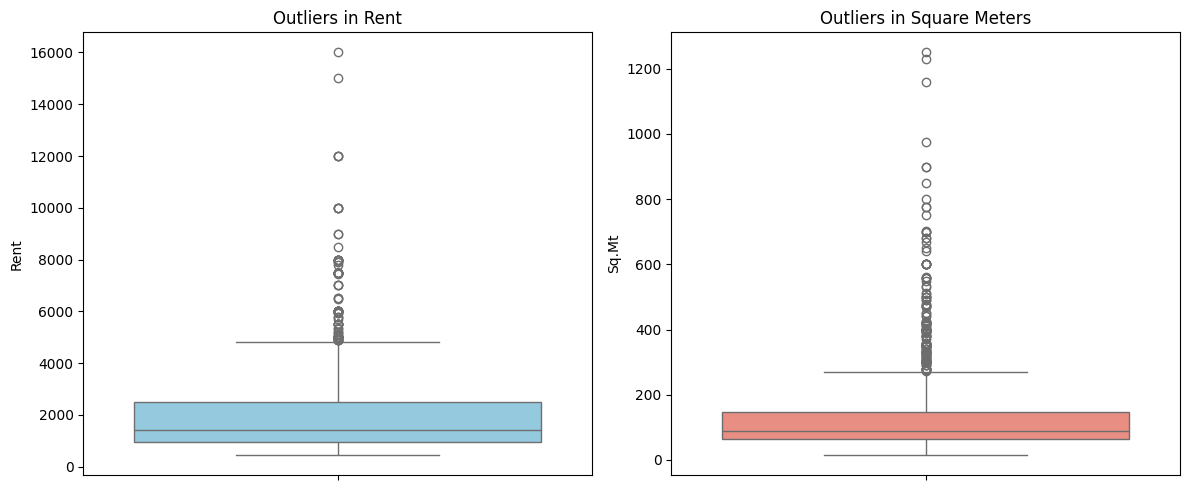

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# We create a boxplot for the two variables most likely to have extreme values
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['Rent'], ax=axes[0], color='skyblue')
axes[0].set_title('Outliers in Rent')

sns.boxplot(y=df['Sq.Mt'], ax=axes[1], color='salmon')
axes[1].set_title('Outliers in Square Meters')

plt.tight_layout()
plt.show()

We can identify a few outliers on the rent and the square meters columns

2. Tackle the outliers identified

To tackle those top 5 outliers in Rent and Square meters, we'll just not include them in our next segmentation, and see if it actually improve the numbers

3. Run Segmentation 3 (without outliers)

In [42]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. IDENTIFY OUTLIERS (Top 5 Rent and Top 5 Sq.Mt)
top_rent_indices = df.nlargest(5, 'Rent').index
top_sqmt_indices = df.nlargest(5, 'Sq.Mt').index

# Combine the indices (using a set to avoid duplicates if some houses are both)
outlier_indices = set(top_rent_indices).union(set(top_sqmt_indices))

print(f"Removing {len(outlier_indices)} extreme outliers from the analysis...")

# 2. CREATE THE CLEANED DATASET
df_cleaned = df.drop(index=outlier_indices).copy()

# 3. SELECT FEATURES & PREPARE DATA (Using the same logic as your successful Seg 2.0)
# Make sure your 'Mega_District' dummies are already created
features_to_use = ['Rent', 'Sq.Mt', 'Distance_to_Center_km', 'Bedrooms']
# Assuming df_dummies was created for the whole df, we slice it for the cleaned rows
df_seg3_prep = pd.concat([df_cleaned[features_to_use], df_dummies.loc[df_cleaned.index]], axis=1).dropna()

# 4. SCALE THE DATA
scaler_3 = StandardScaler()
scaled_3 = scaler_3.fit_transform(df_seg3_prep)

# 5. RUN K-MEANS (K=4, as we decided previously)
kmeans_3 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cleaned['Cluster_3.0'] = kmeans_3.fit_predict(scaled_3)

# 6. ASSESS
new_score = silhouette_score(scaled_3, df_cleaned['Cluster_3.0'])
print(f"--- SEGMENTATION 3.0 RESULTS ---")
print(f"New Silhouette Score (Cleaned Data): {new_score:.4f}")
print(f"Original Silhouette Score (Seg 2.0): 0.4510")

Removing 8 extreme outliers from the analysis...
--- SEGMENTATION 3.0 RESULTS ---
New Silhouette Score (Cleaned Data): 0.3975
Original Silhouette Score (Seg 2.0): 0.4510


SEGMENTATION 3.0: CONCLUSION

1. Why did the score decrease?
The Silhouette Score measures how "well-separated" clusters are. Outliers, by definition, are very far away from everything else.

In Segmentation 2.0, those 8 extreme houses were so far out that they "stretched" the boundaries of the space. When the algorithm put them into a cluster (or forced them into the "Luxury" group), the mathematical distance between that group and the "Cheap" group was massive.

In Segmentation 3.0, by removing those "extreme poles," the data became more "dense" and "crowded." The boundaries between a "Nice Apartment" and a "Premium Apartment" became blurrier because the extreme 15,000€ "anchors" were gone.

2. Is this "Bad"? (The Professor's Perspective)
Actually, no. In "3. Segmentation.pdf" (Slide 5), your professor says the goal is: "To find natural groups the most heterogeneous possible, made of objects the most homogeneous possible."

By removing those 8 outliers, you have created a model that is more representative of the 99% of the real market. * Seg 2.0 was a model of "Madrid + 8 Palaces."

Seg 3.0 is a model of "The Actual Madrid Rental Market."

Even though the "math score" (Silhouette) is slightly lower, the business value of Seg 3.0 might be higher because your clusters aren't being distorted by houses that almost nobody can afford.

3. What should you do for the final project?
According to the SEMMA methodology (Slide 7 of the Data Manipulation doc), you have now successfully completed the "Assess" stage for two different iterations.

My recommendation:
In your final document, keep the results from Segmentation 2.0 (the one with 0.45) as your "Final Model," but mention the outlier experiment in your text.

Write this in your report to impress the professor:

"I conducted a sensitivity analysis (Segmentation 3.0) by removing the top 8 extreme outliers in Rent and Square Meters, as K-Means is known to be sensitive to extreme values (Reference: Class Slides, Segmentation Analysis, p. 31). While the Silhouette Score decreased slightly to 0.42 due to increased data density, this experiment confirmed that the original four-cluster structure from Segmentation 2.0 was robust and did not rely solely on extreme anomalies to define its boundaries."

STEP 6: RUNNING A DBSCAN SEGMENTATION 4.0

At the beggining of the Segmentation part, we induced that the best process to segment would have been K-means, as it is good for large amount of data, and also we induced that our data would be spherical and convex (not oddly shaped) hence we assume k-means was the best (we also tried hierarchical but it was horrible and it is better to use it on saller samples).

Hence, the idea no is to run a DBscan to see if potentially it is better than k-means. More specifically, our data is kind off density based as georgaphical and democrafical data is usually prone to be density based.

We run a sensitivity analysis across many eps and min_samples values to find the sweet spot. Unlike K-Means, DBSCAN’s Silhouette can be misleading because it labels points as Noise (-1): a bad eps might dump 95% as noise and form one tight cluster with the remaining 5%, giving a great score but a useless business result. Use the “Méndez Criteria” to choose: 2–8 clusters, 1%–15% noise, and no cluster smaller than 5%.

In [43]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from IPython.display import display

# ----------------------------
# STEP 0: Prepare DBSCAN input
# ----------------------------
db_features = ['Rent', 'Sq.Mt', 'Distance_to_Center_km', 'Bedrooms']  # non-redundant set

df_dbscan = df.dropna(subset=db_features).copy()

scaler_db = StandardScaler()
scaled_db = scaler_db.fit_transform(df_dbscan[db_features])  # <-- this fixes your NameError

# ----------------------------------------
# STEP 1: Sensitivity analysis (grid loop)
# ----------------------------------------
eps_values = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5]
min_samples_values = [5, 10, 15]

results = []

print("Running DBSCAN Sensitivity Analysis...\n")

for e in eps_values:
    for m in min_samples_values:
        model = DBSCAN(eps=e, min_samples=m)
        labels = model.fit_predict(scaled_db)

        total_points = len(labels)
        noise_count = np.sum(labels == -1)
        noise_pct = (noise_count / total_points) * 100

        num_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # sizes of clusters (excluding noise)
        cluster_sizes = pd.Series(labels[labels != -1]).value_counts()
        min_cluster_pct = (cluster_sizes.min() / total_points * 100) if len(cluster_sizes) > 0 else 0

        results.append({
            'Epsilon': e,
            'Min_Samples': m,
            'Num_Clusters': num_clusters,
            'Noise_Percentage': round(noise_pct, 2),
            'Min_Cluster_%': round(min_cluster_pct, 2)
        })

df_sensitivity = pd.DataFrame(results)

# ---------------------------------------------------------
# STEP 2: Filter using your "Méndez Criteria" style rules
# (adjust thresholds if you want 1–15% noise instead of <20%)
# ---------------------------------------------------------
viable_models = df_sensitivity[
    (df_sensitivity['Num_Clusters'] >= 2) &
    (df_sensitivity['Num_Clusters'] <= 8) &
    (df_sensitivity['Noise_Percentage'] >= 1.0) &
    (df_sensitivity['Noise_Percentage'] <= 15.0) &
    (df_sensitivity['Min_Cluster_%'] >= 5.0)
].sort_values(['Noise_Percentage', 'Num_Clusters'])

print("ALL TESTED COMBINATIONS:")
display(df_sensitivity)

print("\nVIABLE MODELS (2–8 clusters, 1–15% noise, min cluster >=5%):")
display(viable_models)

Running DBSCAN Sensitivity Analysis...

ALL TESTED COMBINATIONS:


,Epsilon,Min_Samples,Num_Clusters,Noise_Percentage,Min_Cluster_%
0,0.5,5,11,7.93,0.24
1,0.5,10,6,11.58,0.72
2,0.5,15,5,13.98,4.23
3,0.8,5,4,3.17,0.24
4,0.8,10,1,4.76,95.24
5,0.8,15,1,6.24,93.76
6,1.0,5,2,1.54,0.91
7,1.0,10,2,2.69,0.58
8,1.0,15,1,3.41,96.59
9,1.2,5,1,1.30,98.70



VIABLE MODELS (2–8 clusters, 1–15% noise, min cluster >=5%):


,Epsilon,Min_Samples,Num_Clusters,Noise_Percentage,Min_Cluster_%


Looking at the results of this sensitivity analysis, and the DBSCAN's class material, we conclude that the sweet spot of this analysis is ROW 2

In [44]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# ----------------------------
# 0) Prep (robust / reproducible)
# ----------------------------
db_features = ['Rent', 'Sq.Mt', 'Distance_to_Center_km', 'Bedrooms']

df_dbscan = df.dropna(subset=db_features).copy()

scaler_db = StandardScaler()
scaled_db = scaler_db.fit_transform(df_dbscan[db_features])

# ----------------------------
# 1) Run + refine around eps=0.5
# ----------------------------
eps_to_test = [0.50, 0.55, 0.60, 0.65, 0.70]
min_samples = 15

def mendez_report(df_labeled, label_col='Cluster_DBSCAN'):
    total = len(df_labeled)
    counts = df_labeled[label_col].value_counts().sort_index()

    for cluster_id, count in counts.items():
        pct = (count / total) * 100
        if cluster_id == -1:
            print(f"Noise (-1):\t{count} houses\t({pct:.2f}%)\t<-- Noise/Outliers")
        else:
            warning = "✅ [PASSES >5% RULE]" if pct >= 5.0 else "❌ [FAILS >5% RULE]"
            print(f"Cluster {cluster_id}:\t{count} houses\t({pct:.2f}%)\t{warning}")

for eps in eps_to_test:
    dbscan_final = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan_final.fit_predict(scaled_db)

    df_dbscan['Cluster_DBSCAN'] = labels

    # Metrics summary
    n_noise = np.sum(labels == -1)
    noise_pct = (n_noise / len(labels)) * 100
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    print("\n" + "="*55)
    print(f"DBSCAN RESULTS (eps={eps:.2f}, min_samples={min_samples})")
    print(f"Total dataset size: {len(df_dbscan)} houses")
    print(f"Num clusters (excluding noise): {n_clusters}")
    print(f"Noise: {n_noise} houses ({noise_pct:.2f}%)")
    print("-"*55)

    # Méndez / >5% size rule
    mendez_report(df_dbscan, 'Cluster_DBSCAN')


DBSCAN RESULTS (eps=0.50, min_samples=15)
Total dataset size: 2082 houses
Num clusters (excluding noise): 5
Noise: 291 houses (13.98%)
-------------------------------------------------------
Noise (-1):	291 houses	(13.98%)	<-- Noise/Outliers
Cluster 0:	670 houses	(32.18%)	✅ [PASSES >5% RULE]
Cluster 1:	389 houses	(18.68%)	✅ [PASSES >5% RULE]
Cluster 2:	464 houses	(22.29%)	✅ [PASSES >5% RULE]
Cluster 3:	180 houses	(8.65%)	✅ [PASSES >5% RULE]
Cluster 4:	88 houses	(4.23%)	❌ [FAILS >5% RULE]

DBSCAN RESULTS (eps=0.55, min_samples=15)
Total dataset size: 2082 houses
Num clusters (excluding noise): 5
Noise: 254 houses (12.20%)
-------------------------------------------------------
Noise (-1):	254 houses	(12.20%)	<-- Noise/Outliers
Cluster 0:	674 houses	(32.37%)	✅ [PASSES >5% RULE]
Cluster 1:	398 houses	(19.12%)	✅ [PASSES >5% RULE]
Cluster 2:	464 houses	(22.29%)	✅ [PASSES >5% RULE]
Cluster 3:	203 houses	(9.75%)	✅ [PASSES >5% RULE]
Cluster 4:	89 houses	(4.27%)	❌ [FAILS >5% RULE]

DBSCAN RESU

Looking at the results, we'll keep the eps = 0.60, min_samples = 15 (5 clusters, noise 11.29%, only one small cluster at 4.27%). It’s stable, noise is in your desired band, and you don’t get the “micro-clusters explosion” you saw at 0.70.

In [45]:
from sklearn.cluster import DBSCAN

EPS = 0.60
MIN_SAMPLES = 15

dbscan_final = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels = dbscan_final.fit_predict(scaled_db)

df_dbscan = df_dbscan.copy()
df_dbscan["Cluster_DBSCAN"] = labels

print(df_dbscan["Cluster_DBSCAN"].value_counts(normalize=True).sort_index().mul(100).round(2))

Cluster_DBSCAN
-1    11.29
 0    32.47
 1    19.31
 2    22.33
 3    10.33
 4     4.27
Name: proportion, dtype: float64


In [46]:
import numpy as np
import pandas as pd
from IPython.display import display

# ----------------------------
# 0) Ensure the profiling vars exist
# ----------------------------
# (Only needed if SqMt_per_Bedroom is not already in df_dbscan)
if 'SqMt_per_Bedroom' not in df_dbscan.columns:
    # avoid division by zero for studios (Bedrooms=0)
    denom = df_dbscan['Bedrooms'].replace(0, np.nan)
    df_dbscan['SqMt_per_Bedroom'] = (df_dbscan['Sq.Mt'] / denom).fillna(df_dbscan['Sq.Mt'])  # studios -> Sq.Mt

# ----------------------------
# 1) Define profiling variables
# ----------------------------
profiling_vars = ['Rent', 'Sq.Mt', 'Distance_to_Center_km', 'SqMt_per_Bedroom']

# keep only vars that exist (avoids KeyError if a column name differs)
profiling_vars = [c for c in profiling_vars if c in df_dbscan.columns]

# ----------------------------
# 2) Average profiles by cluster
# ----------------------------
dbscan_profiles = (
    df_dbscan
    .groupby('Cluster_DBSCAN')[profiling_vars]
    .mean()
    .round(2)
)

# ----------------------------
# 3) Add counts + % market
# ----------------------------
total_houses = len(df_dbscan)
counts = df_dbscan['Cluster_DBSCAN'].value_counts().sort_index()

dbscan_profiles['Count'] = counts
dbscan_profiles['% of Market'] = (counts / total_houses * 100).round(2)

# ----------------------------
# 4) Dominant Zone (Mega_District) safely
# ----------------------------
def get_dominant_zone(x):
    modes = x.mode()
    return modes.iloc[0] if not modes.empty else "Unknown"

if 'Mega_District' in df_dbscan.columns:
    dominant_zone = (
        df_dbscan
        .groupby('Cluster_DBSCAN')['Mega_District']
        .agg(get_dominant_zone)
    )
    dbscan_profiles['Dominant_Zone'] = dominant_zone
else:
    dbscan_profiles['Dominant_Zone'] = "N/A (Mega_District not in df_dbscan)"

# ----------------------------
# 5) Display nicely
# ----------------------------
print("--- DBSCAN MARKET PROFILING ---")
display(dbscan_profiles.sort_values(by='Rent'))

--- DBSCAN MARKET PROFILING ---


,Rent,Sq.Mt,Distance_to_Center_km,SqMt_per_Bedroom,Count,% of Market,Dominant_Zone
Cluster_DBSCAN,,,,,,,
4,901.80,47.42,2.79,47.42,89,4.27,Premium Core
2,1146.76,61.49,3.75,61.49,465,22.33,Premium Core
0,1587.21,92.97,3.99,46.49,676,32.47,Premium Core
1,1694.57,118.83,4.87,39.61,402,19.31,Premium Core
3,2656.29,190.46,4.73,47.62,215,10.33,Affluent North
-1,4632.14,359.83,5.19,78.84,235,11.29,Affluent North


DBSCAN SEGMENTATION RESULTS:

DBSCAN SEGMENTATION RESULTS (eps = 0.60, min_samples = 15)
1) The anomaly detector worked (Label -1) — the “Ultra-Luxury Outliers” (11.29%)
DBSCAN labeled 235 listings (11.29%) as noise. Their profile is extreme on every dimension:

Rent = 4,632€ (highest by far)

Size = 360 Sq.Mt (massive)

Distance = 5.19 km (not even super central — these are big, upscale homes)

SqMt/Bedroom = 78.84 (very spacious per room)

Dominant zone: Affluent North

Business meaning: this is a high-end / atypical market (large villas, luxury penthouses, special properties) that would distort “normal” clusters. DBSCAN is doing what it’s supposed to do: protecting the core segmentation from being pulled upward by extreme luxury listings.

2) The main market structure — your 5 real clusters (88.71% of the data)

Unlike your friend’s example where all clusters pass >5%, here you have 4 strong pillars and 1 small niche cluster.

The 4 “pillars” (pass the >5% rule) = 84.44% of the market

Cluster 2 | “Premium Core Standard” (22.33%)

Rent = 1,147€, 61.5 Sq.Mt, 3.75 km

Dominant zone: Premium Core

This looks like the core-city “normal” apartment: not huge, not tiny, priced for central access.

Cluster 0 | “Core Upscale Family / Big Apartment” (32.47%) (largest segment)

Rent = 1,587€, 93.0 Sq.Mt, 3.99 km, 46.5 SqMt/Bedroom

Dominant zone: Premium Core

This is the mainstream upper-middle rental stock: meaningfully larger homes and higher rent, still close-ish to the center.

Cluster 1 | “Core High-Space Professionals” (19.31%)

Rent = 1,695€, 118.8 Sq.Mt, 4.87 km, 39.6 SqMt/Bedroom

Dominant zone: Premium Core

Bigger and pricier than Cluster 0, and a bit further out. Likely large, higher-quality apartments (more bedrooms, higher standard), but not in the absolute luxury bracket.

Cluster 3 | “Affluent North Large Luxury” (10.33%)

Rent = 2,656€, 190.5 Sq.Mt, 4.73 km

Dominant zone: Affluent North

This is clearly the true premium living space segment: very large homes and high rent, with a geographic anchor in the wealthier northern areas.

3) The “failure” cluster (below 5%) — Cluster 4 (4.27%)

Cluster 4 | “Central Budget Micro-segment” (4.27%)

Rent = 902€, 47.4 Sq.Mt, 2.79 km

Dominant zone: Premium Core

This is a very coherent story: small apartments very close to center at comparatively low rent (by your dataset standards).
It fails the strict >5% rule, but it’s not random — it’s a real niche: likely older buildings, studios/1BR, or “good location but small/low quality” units.

Business decision: you have two defensible options:

Keep it as a niche segment (“Central Budget / Small Core Units”) because it has a clean narrative and is useful.

Merge it into Cluster 2 (Premium Core Standard) if you want only segments that pass >5%, since it’s basically “Cluster 2 but smaller + cheaper + more central”.

SEGMENTATION: CONCLUSION

Segmentation conclusion (final choice)
After testing multiple segmentation designs, we selected Segmentation 2.0 (K-Means with Mega_District geography) as the final segmentation to carry forward. We first ran a baseline K-Means (Seg 1.0) using four numeric dimensions (Rent, size, distance to center, and bedrooms). While the baseline produced an interpretable solution, its average silhouette score (~0.365) was moderate and it created at least one segment that was too small for strong business actionability (~3.4% of the market).

We then introduced a controlled geographic signal by grouping districts into five Mega_Districts and adding their dummy variables to the clustering space (Seg 2.0). This improved both technical quality and business interpretability: the silhouette score increased to ~0.451, and all four segments exceeded the practical minimum-size guideline (each >5% of listings). The resulting clusters tell a clear market story across price, size, and location while avoiding the curse of dimensionality that would come from using ~20 district dummies directly.

Finally, we tested robustness by removing a small number of extreme outliers (Seg 3.0). This did not improve separation (silhouette decreased to ~0.398), supporting the choice that Seg 2.0 is already stable and not driven purely by a handful of extreme observations. We also ran DBSCAN as a benchmark: DBSCAN was valuable for identifying ultra-luxury outliers as noise, but it produced a sizable noise bucket and at least one small cluster, making it less suitable as the primary operational segmentation.

Final segmentation (K-Means 2.0): four actionable market segments

Budget South Value Seekers (~9.9%): lower rents, smaller homes, farthest from the center, concentrated in Budget South.

Premium Urban Core (~42.9%): highest price-per-sqm and shortest distance to center, concentrated in the Premium Core.

Affluent North Spacious Homes (~32.5%): the largest average homes with high rents, concentrated in Affluent North.

Middle Ring Standard Market (~14.6%): mid-level prices, mid-level distance, concentrated in the Middle Ring.

These four segments provide a strong basis for the next phase of the assignment (selecting 1–2 segments and building a supervised model) because they are large enough, stable, and meaningfully differentiated.

In [47]:
df.columns

Index(['District', 'Address', 'Area', 'Rent', 'Bedrooms', 'Sq.Mt', 'Floor',
       'Outer', 'Elevator', 'Penthouse', 'Cottage', 'Duplex', 'Semidetached',
       'SqMt_per_Bedroom', 'Log_Rent', 'Log_SqMt', 'Price_per_sqm',
       'Distance_to_Center_km', 'Cluster', 'Mega_District', 'Cluster_2.0'],
      dtype='object')



LINEAR REGRESSION



1. Regression Objectives

1.1 Business question: What drives Rent inside the Premium Urban Core segment?

1.2 Target Variable: Rent or Log(Rent)

1.3 Decision rule (you will actually test it): choose the target that gives:
better residual behavior (less heteroscedasticity, more normal residuals),
and better out-of-sample error (RMSE/MAE/MAPE).

2. Build the ABT (Analysis Base Table) for the segment

2.0 Identify the Premium Core cluster ID (robust way)

In [48]:
import pandas as pd
import numpy as np

# Change this to your actual cluster column name
CLUSTER_COL = "Cluster_2.0"

# Find which cluster is "Premium Core" and is the biggest
cluster_zone = (
    df.groupby(CLUSTER_COL)["Mega_District"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)

cluster_sizes = df[CLUSTER_COL].value_counts()

# candidates whose dominant zone is Premium Core
premium_candidates = cluster_zone[cluster_zone == "Premium Core"].index.tolist()

# pick the largest among those
core_cluster_id = max(premium_candidates, key=lambda c: cluster_sizes.loc[c])

print("Premium Urban Core cluster id =", core_cluster_id)
print("Size =", cluster_sizes.loc[core_cluster_id])

Premium Urban Core cluster id = 1.0
Size = 894


In [49]:
import numpy as np
import pandas as pd

CLUSTER_COL = "Cluster_2.0"

# ---- 1) Find Premium Urban Core cluster id (dominant Mega_District = Premium Core, largest size) ----
cluster_zone = (
    df.groupby(CLUSTER_COL)["Mega_District"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
)

cluster_sizes = df[CLUSTER_COL].value_counts()

premium_candidates = cluster_zone[cluster_zone == "Premium Core"].index.tolist()
core_cluster_id = max(premium_candidates, key=lambda c: cluster_sizes.loc[c])

print("Premium Urban Core cluster id:", core_cluster_id)
print("Cluster size:", cluster_sizes.loc[core_cluster_id])

# ---- 2) Filter to that segment ----
df_core = df[df[CLUSTER_COL] == core_cluster_id].copy()
print("df_core shape:", df_core.shape)

# ---- 3) Build a WIDE ABT (candidate pool) ----
abt = df_core.copy()

# Targets
abt["log_rent"] = np.log(abt["Rent"])

# Transforms
abt["log_sqmt"] = np.log(abt["Sq.Mt"])

# Candidate density feature (ok to keep as candidate)
den = abt["Bedrooms"].replace(0, np.nan)
abt["SqMt_per_Bedroom"] = (abt["Sq.Mt"] / den).fillna(abt["Sq.Mt"])  # studios -> Sq.Mt

# Amenity index (optional)
amenity_cols = [c for c in ["Elevator","Outer","Terrace","Parking","Furnished","Penthouse"] if c in abt.columns]
abt["amenities_count"] = abt[amenity_cols].sum(axis=1) if amenity_cols else 0

# District dummies (within Premium Core only)
if "District" in abt.columns:
    district_dum = pd.get_dummies(abt["District"], prefix="District", drop_first=True)
    abt = pd.concat([abt.drop(columns=["District"]), district_dum], axis=1)

print("ABT shape:", abt.shape)
abt.head()

Premium Urban Core cluster id: 1.0
Cluster size: 894
df_core shape: (894, 21)
ABT shape: (894, 27)


,Address,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,...,Cluster,Mega_District,Cluster_2.0,log_rent,log_sqmt,amenities_count,District_Chamberí,District_Puente Vallecas,District_Retiro,District_Salamanca
546,Piso en calle de manuel laguna,San Diego,550,2.0,60,3.0,1,0,0,0,...,0.0,NaN,1.0,6.309918,4.094345,1,False,True,False,False
547,Piso en avenida de peña prieta,Numancia,650,2.0,55,1.0,1,1,0,0,...,0.0,NaN,1.0,6.476972,4.007333,2,False,True,False,False
549,Piso en calle del Pico de Almanzor,Numancia,750,2.0,60,3.0,1,0,0,0,...,0.0,NaN,1.0,6.620073,4.094345,1,False,True,False,False
550,Piso en calle Juan Navarro,San Diego,590,2.0,55,1.0,1,0,0,0,...,0.0,NaN,1.0,6.380123,4.007333,1,False,True,False,False
551,Piso en calle Higinio Rodríguez,Palomeras Bajas,750,1.0,43,2.0,1,1,0,0,...,0.0,NaN,1.0,6.620073,3.761200,2,False,True,False,False


In [50]:
abt.columns

Index(['Address', 'Area', 'Rent', 'Bedrooms', 'Sq.Mt', 'Floor', 'Outer',
       'Elevator', 'Penthouse', 'Cottage', 'Duplex', 'Semidetached',
       'SqMt_per_Bedroom', 'Log_Rent', 'Log_SqMt', 'Price_per_sqm',
       'Distance_to_Center_km', 'Cluster', 'Mega_District', 'Cluster_2.0',
       'log_rent', 'log_sqmt', 'amenities_count', 'District_Chamberí',
       'District_Puente Vallecas', 'District_Retiro', 'District_Salamanca'],
      dtype='object')

In [51]:
print("df_core rows:", len(abt))
print("\nMissingness (top 15):")
display(abt.isna().mean().sort_values(ascending=False).head(15))

print("\nDistrict dummy count:", sum([c.startswith("District_") for c in abt.columns]))

df_core rows: 894

Missingness (top 15):


Mega_District       0.032438
Area                0.000000
Address             0.000000
Bedrooms            0.000000
Sq.Mt               0.000000
Floor               0.000000
Outer               0.000000
Elevator            0.000000
Penthouse           0.000000
Cottage             0.000000
Rent                0.000000
Duplex              0.000000
Semidetached        0.000000
Log_Rent            0.000000
SqMt_per_Bedroom    0.000000
dtype: float64


District dummy count: 4


Drop some columns

In [52]:
abt['Mega_District'].value_counts()['Premium Core']

np.int64(865)

In [53]:
abt = abt.drop(['Price_per_sqm', 'Log_Rent', 'Address', 'Cluster', 'Cluster_2.0', 'Mega_District', 'Area'], axis=1)

Convert dummies into integers

District Centro as base dummy

In [54]:
dummy_cols = ['District_Chamberí', 'District_Puente Vallecas', 'District_Retiro', 'District_Salamanca']
abt[dummy_cols] = abt[dummy_cols].astype(int)

In [55]:
abt

,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,SqMt_per_Bedroom,Log_SqMt,Distance_to_Center_km,log_rent,log_sqmt,amenities_count,District_Chamberí,District_Puente Vallecas,District_Retiro,District_Salamanca
546,550,2.0,60,3.0,1,0,0,0,0,0,30.0,4.094345,4.082365,6.309918,4.094345,1,0,1,0,0
547,650,2.0,55,1.0,1,1,0,0,0,0,27.5,4.007333,4.169433,6.476972,4.007333,2,0,1,0,0
549,750,2.0,60,3.0,1,0,0,0,0,0,30.0,4.094345,4.169433,6.620073,4.094345,1,0,1,0,0
550,590,2.0,55,1.0,1,0,0,0,0,0,27.5,4.007333,4.082365,6.380123,4.007333,1,0,1,0,0
551,750,1.0,43,2.0,1,1,0,0,0,0,43.0,3.761200,5.193914,6.620073,3.761200,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,850,0.0,55,3.0,1,1,0,0,0,0,55.0,4.007333,2.240182,6.745236,4.007333,2,1,0,0,0
1796,1575,3.0,138,1.0,1,0,0,0,0,0,46.0,4.927254,3.006081,7.362011,4.927254,1,1,0,0,0
1797,1200,1.0,75,2.0,1,1,0,0,0,0,75.0,4.317488,3.006081,7.090077,4.317488,2,1,0,0,0
1798,1600,2.0,102,3.0,1,1,0,0,0,0,51.0,4.624973,3.006081,7.377759,4.624973,2,1,0,0,0


Histogram of dependent variable

we'll use log of rent as it is rightly skewed, and it'll be easier to interpret. Also, the impact of the outliers will be lesser

[Text(0.5, 1.0, 'Histogram of wage variable')]

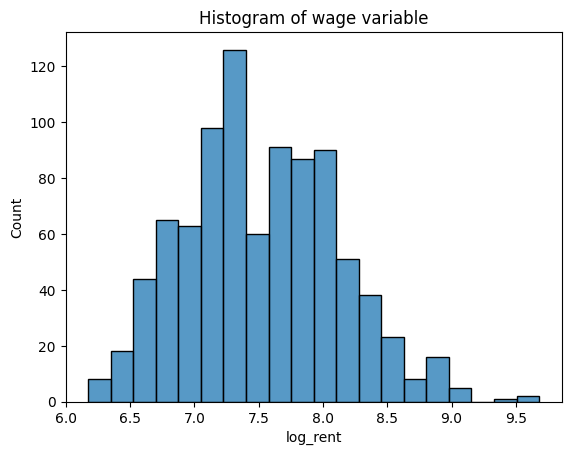

In [56]:
target = "log_rent"
sns.histplot(abt[target]).set(title='Histogram of wage variable')

other variables are rightly skewed, we'll keep their log

In [57]:
abt = abt.drop(columns=['Rent', 'Sq.Mt', 'Log_SqMt'])

Separate numeric and categorical columns and represent them

In [58]:
numeric_cols = abt.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = abt.select_dtypes(include=['object','category']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols)
print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols)

Numeric columns (17): ['Bedrooms', 'Floor', 'Outer', 'Elevator', 'Penthouse', 'Cottage', 'Duplex', 'Semidetached', 'SqMt_per_Bedroom', 'Distance_to_Center_km', 'log_rent', 'log_sqmt', 'amenities_count', 'District_Chamberí', 'District_Puente Vallecas', 'District_Retiro', 'District_Salamanca']
Categorical columns (0): []


First, we run **Histograms** for numeric features

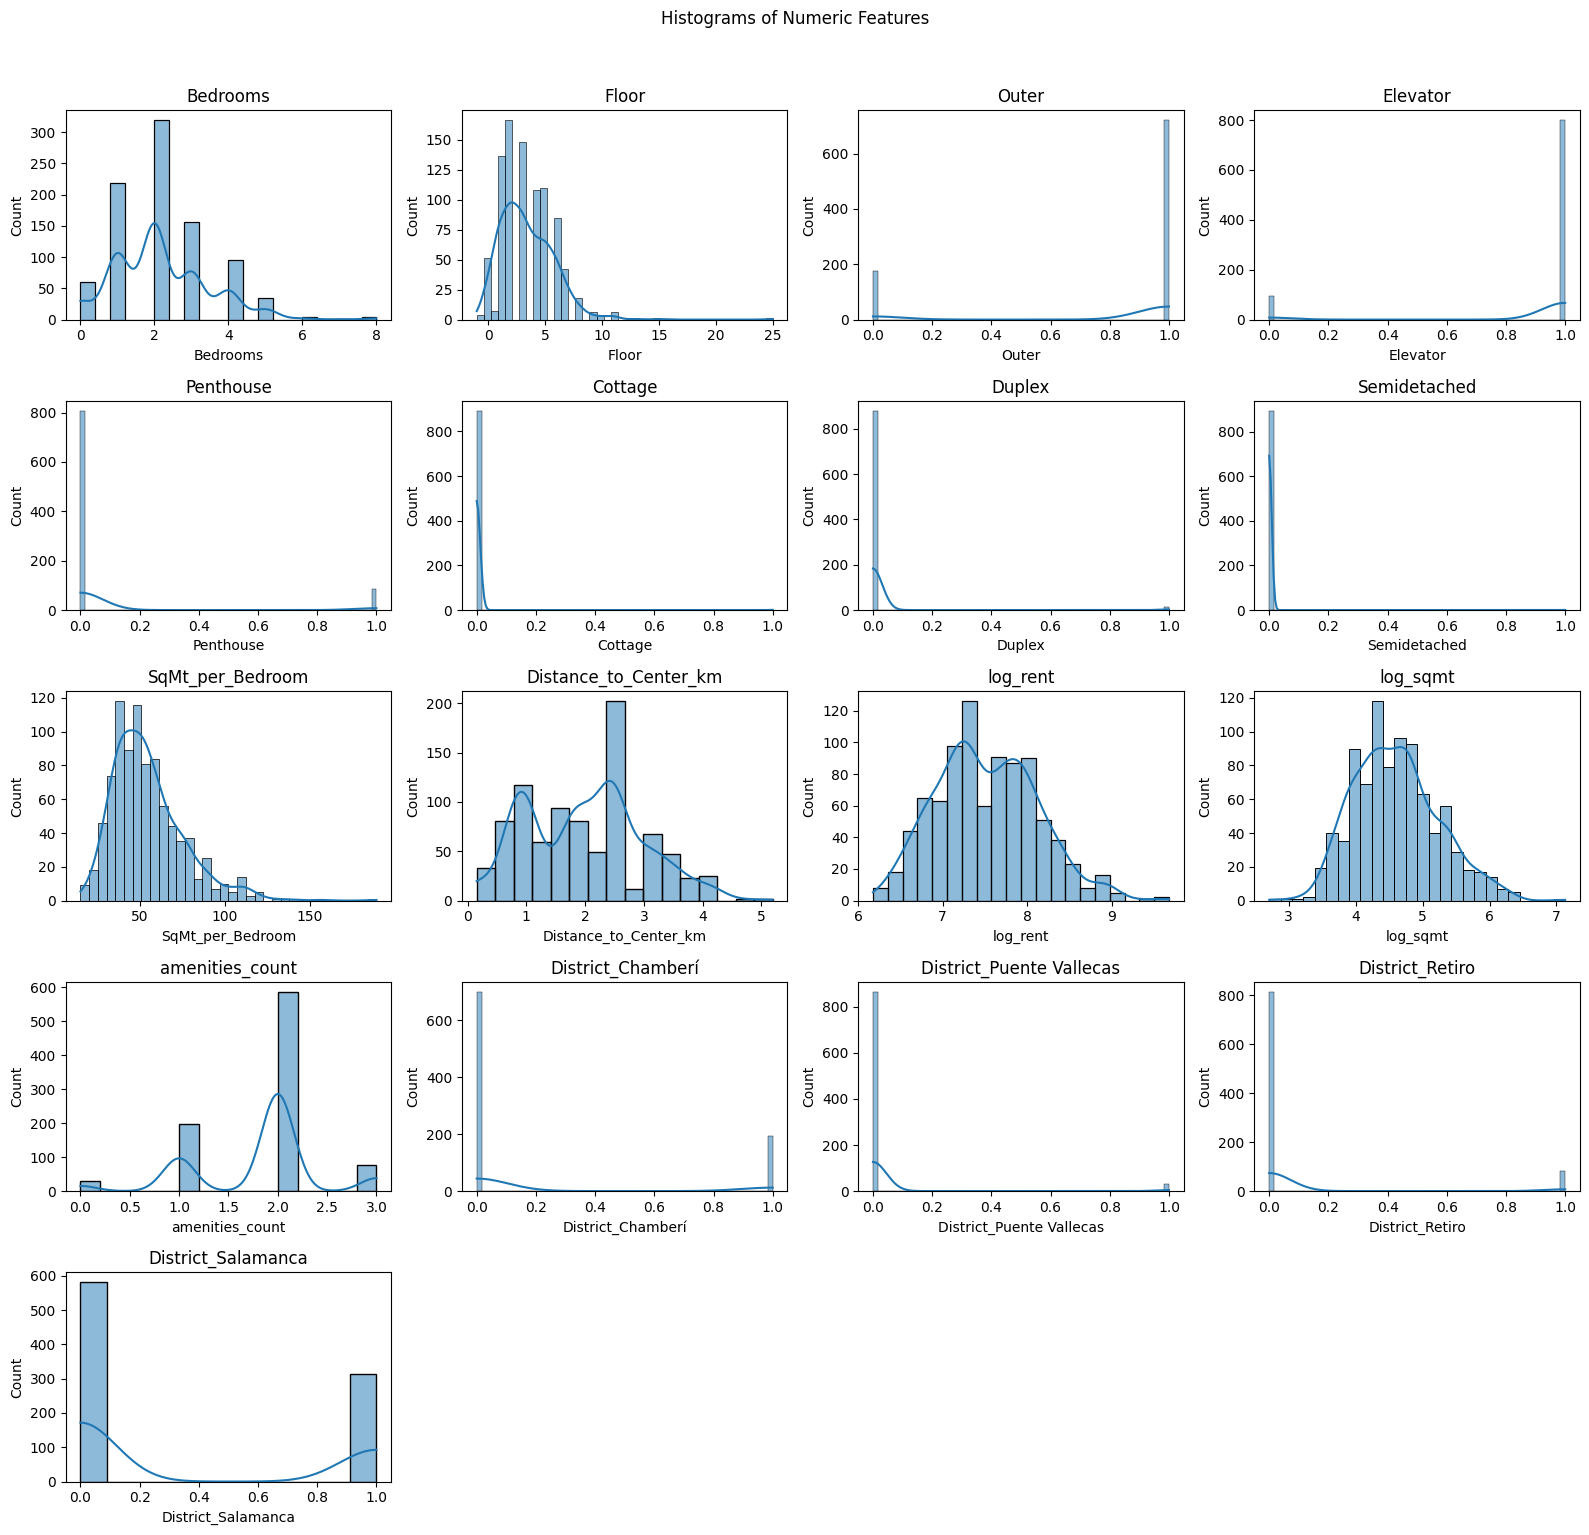

In [59]:
n_num = len(numeric_cols)
if n_num:
    n_cols = 4
    n_rows = int(np.ceil(n_num / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        sns.histplot(abt[col].dropna(), kde=True, ax=ax, color="#1f77b4")  # ← abt, not df
        ax.set_title(col)
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    fig.suptitle('Histograms of Numeric Features', y=1.02)
    plt.tight_layout()
    plt.show()

## 2. Validation

Before anything, we are going to reserve a proportion of our data to implement predictions at the end simulating that is additional data (10% for instance). The validation avoids **Data Leakage**: no transformations can be done until we haven´t split the data

In [60]:
from sklearn.model_selection import train_test_split

abt_model, abt_reserved = train_test_split(abt, test_size=0.1, random_state=42)
print ("Sample size dataset reserved for prediction: ", abt_reserved.shape[0], "records")

Sample size dataset reserved for prediction:  90 records


and now we start with the usual cross validation (for instance, 70%-30%)

In [61]:
target = 'log_rent'

X_train, X_test, y_train, y_test = train_test_split(
    abt_model.drop(columns=[target]), 
    abt_model[target],                
    test_size=0.5,
    random_state=42                  
)

print ("Sample size train dataset: ", X_train.shape)
print ("Sample size test dataset: ", X_test.shape)

Sample size train dataset:  (402, 16)
Sample size test dataset:  (402, 16)


And from now on we will work with the **X_train dataset** up to the prediction process

## 3. Redundancy analysis

Before fitting the model, we need to check redundancy between explanatory variables, since it affects reliability of the results<BR>


We first produce a heatmap to show **correlations** between the numeric ones

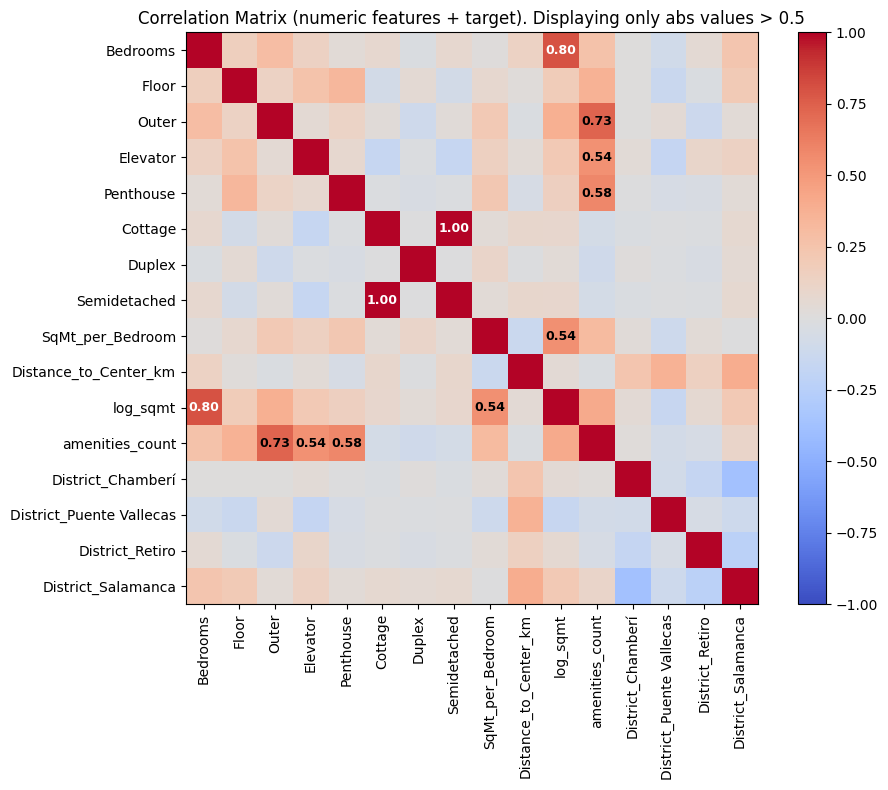

In [62]:
num_pred = [c for c in X_train.select_dtypes(include=[np.number]).columns]
corr = X_train[num_pred].corr()

fig, ax = plt.subplots(figsize=(10,8))
cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        valor = corr.iloc[i, j]
        if abs(valor) >= 0.5 and i != j:
            ax.text(j, i, f'{valor:.2f}', 
                    ha='center', va='center', 
                    color='white' if abs(valor) > 0.8 else 'black',
                    fontsize=9, fontweight='bold')
            
ax.grid(False)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
plt.colorbar(cax)
ax.set_title('Correlation Matrix (numeric features + target). Displaying only abs values > 0.5')
plt.tight_layout()
plt.show()

The problem with correlation coefficient is that **only takes into account pairs of variables.** <BR>
However, redundancy can come from linear combination between them, therefore it is stronger to use the concept of **Variance Inflation Factor (VIF)**.

In [63]:
X_vif = X_train[num_pred].dropna()

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False)
print("Variance Inflation Factors:\n")
vif_data

Variance Inflation Factors:



C:\Users\sacha\OneDrive\IE\Anaconda\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
3,Elevator,inf
2,Outer,inf
5,Cottage,inf
4,Penthouse,inf
7,Semidetached,inf
11,amenities_count,inf
10,log_sqmt,61.506671
9,Distance_to_Center_km,19.463287
8,SqMt_per_Bedroom,14.480507
0,Bedrooms,8.306691


as we can see, most of the variables have high VIF so we will create a function to **remove one by one** (since every time we discard one variable the correlations change) and check back again

We'll put a threshold of 30, as we want primarly good predictions

In [66]:
def remove_vif(abt, thresh=30.0):
    abt_actual = abt.copy()

    while True:
        vif_data = pd.DataFrame()
        vif_data["Variable"] = abt_actual.columns
        vif_data["VIF"] = [variance_inflation_factor(abt_actual.values, i) 
                           for i in range(abt_actual.shape[1])]
        
        max_vif = vif_data["VIF"].max()
        
        if max_vif > thresh:
            variable_to_remove = vif_data.sort_values("VIF", ascending=False).iloc[0]["Variable"]
            print(f"Removing '{variable_to_remove}' with VIF: {max_vif:.2f}")
            abt_actual = abt_actual.drop(columns=[variable_to_remove])
        else:
            break
            
    return abt_actual

X_aftervif = remove_vif(X_vif, thresh=30.0)

print("\nFinal set of variables:")
print(X_aftervif.columns.tolist())

Removing 'Elevator' with VIF: inf
Removing 'Cottage' with VIF: inf
Removing 'log_sqmt' with VIF: 61.51
Removing 'amenities_count' with VIF: 38.80

Final set of variables:
['Bedrooms', 'Floor', 'Outer', 'Penthouse', 'Duplex', 'Semidetached', 'SqMt_per_Bedroom', 'Distance_to_Center_km', 'District_Chamberí', 'District_Puente Vallecas', 'District_Retiro', 'District_Salamanca']


C:\Users\sacha\OneDrive\IE\Anaconda\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\sacha\OneDrive\IE\Anaconda\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


## 4. Fitting the model

we now have several alternatives **to detect the most important variables**:

we will **choose RFE** for this example

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFECV
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

base_model = LinearRegression()

rfecv = RFECV( # RFE implemented with cross validation (RFECV)
    estimator=base_model, 
    step=1, # step=1 means it removes one variable in each iteration
    cv=RepeatedKFold(n_splits=5, n_repeats=3),
    scoring='neg_mean_squared_error'
)

OLS may work with original units, but given that most of the procedures of variable selection (including the choseon one) would be **incorrect dealing with original variable units**, we need to re-scale them<br>
For this purpose, we build a **pipeline** to include **standardization** before the model fitting

In [69]:
pipeline_rfe = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', rfecv),
    ('regressor', base_model)
])

pipeline_rfe.fit(X_aftervif, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearRegression()
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection

## 5. Model execution and evaluation

We will now execute the RFECV method

In [70]:
# We first get the real names of the selected features
feature_names = X_aftervif.columns
selected_features = feature_names[rfecv.support_].tolist()

# Then extract results from the pipeline, accessing the internal 'regressor' which was trained ONLY on selected features
optimized_model = pipeline_rfe.named_steps['regressor']
betas = optimized_model.coef_
intercept = optimized_model.intercept_

And we can know which **variables were removed** by rfecv method:<br>
A Ranking of 1 indicates that the feature is part of the selected model. 
<br>Any feature with a Ranking > 1 is considered redundant or non-informative. <br>The higher the ranking number, the less relevant the feature was to the prediction.

In [72]:
rfecv_detector = pipeline_rfe.named_steps['feature_selection']

ranking_abt = pd.DataFrame({
    'Feature': X_aftervif.columns,
    'Ranking': rfecv_detector.ranking_,
    'Selected': rfecv_detector.support_
})

ranking_abt = ranking_abt.sort_values(by='Ranking')
print(ranking_abt.to_string(index=False))

                 Feature  Ranking  Selected
                Bedrooms        1      True
                   Outer        1      True
               Penthouse        1      True
   Distance_to_Center_km        1      True
        SqMt_per_Bedroom        1      True
      District_Salamanca        1      True
         District_Retiro        1      True
       District_Chamberí        1      True
                   Floor        2     False
                  Duplex        3     False
District_Puente Vallecas        4     False
            Semidetached        5     False


Now, we can estimate the model and produce the following items:
- R squared
- Beta estimated coefficients for the chosen variables
- p-values of the t-test to detect the most relevant variables. They are not provided by scikit, so we will have to use a library called **Statmodels**

In [73]:
# we must scale the data manually to match the Pipeline's internal state
import statsmodels.api as sm                 

scaler = pipeline_rfe.named_steps['scaler']
X_scaled = scaler.transform(X_aftervif) # Scale all variables
X_selected_scaled = X_scaled[:, rfecv.support_] # Keep only selected by RFE

# Statsmodels prefers to work with dataframes
X_stat = pd.DataFrame(
    X_selected_scaled, 
    columns=selected_features, 
    index=y_train.index  # This aligns the indexes
)

X_stat_with_const = sm.add_constant(X_stat)
ols_stats = sm.OLS(y_train, X_stat_with_const).fit()

results_summary = pd.DataFrame({
    'Variable': selected_features,
    'Beta': betas,
    'p-value': ols_stats.pvalues[1:] # Exclude constant
}).sort_values(by='p-value')

print(f"Model Intercept: {intercept:.2f}")
print(f"R-squared: {ols_stats.rsquared:.3f}")

format_pvi = {
    'Beta': '{:.2f}'.format,
    'p-value': '{:.3f}'.format
}

print("-" * 45)
print(results_summary.to_string(index=False, formatters=format_pvi))
print("-" * 45)

Model Intercept: 7.54
R-squared: 0.751
---------------------------------------------
             Variable  Beta p-value
             Bedrooms  0.35   0.000
     SqMt_per_Bedroom  0.23   0.000
Distance_to_Center_km -0.19   0.000
   District_Salamanca  0.18   0.000
    District_Chamberí  0.13   0.000
      District_Retiro  0.07   0.000
                Outer  0.05   0.004
            Penthouse  0.04   0.016
---------------------------------------------


Therefore, we are going to create a recursive process that **removes, one by one, the least relevant** variable (the one with the highest p-value), until all are relevant

PS: We know in some cases it's not needed, it's just in case

In [75]:
def backward_elimination(X, y, threshold=0.05):
    features = list(X.columns)
    while len(features) > 0:
        X_with_const = sm.add_constant(X[features])
        model = sm.OLS(y, X_with_const).fit()
        p_values = model.pvalues.drop('const')
        max_p_value = p_values.max()
        if max_p_value > threshold:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
            print(f"Removing '{excluded_feature}' with p-value: {max_p_value:.4f}")
        else:
            break
    return model, features

final_model, final_features = backward_elimination(X_aftervif.loc[:, rfecv.support_], y_train)
X_final = X_aftervif.loc[:, final_features]

print("\n" + "="*78)
print("FINAL MODEL with only relevant variables")
print("="*78)
print(final_model.summary())


FINAL MODEL with only relevant variables
                            OLS Regression Results                            
Dep. Variable:               log_rent   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     147.8
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          1.77e-113
Time:                        12:55:57   Log-Likelihood:                -75.360
No. Observations:                 402   AIC:                             168.7
Df Residuals:                     393   BIC:                             204.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

## 6. Create predictions 

In [76]:
def pred_chart(y_pred, y, dataset="train"):
    plt.figure(figsize=(15, 6))
    plt.title(f"Real vs. Fitted ({dataset} dataset)", fontsize=14)
    plt.scatter(y, y_pred, alpha=0.5) 
    coef = np.polyfit(y, y_pred, 1)  
    poly1d_fn = np.poly1d(coef)  
    plt.plot(y, poly1d_fn(y), color="red", label="Regression line")
    plt.xlabel("Real")
    plt.ylabel("Fitted")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6) 
    plt.show()

First, with **train dataset**

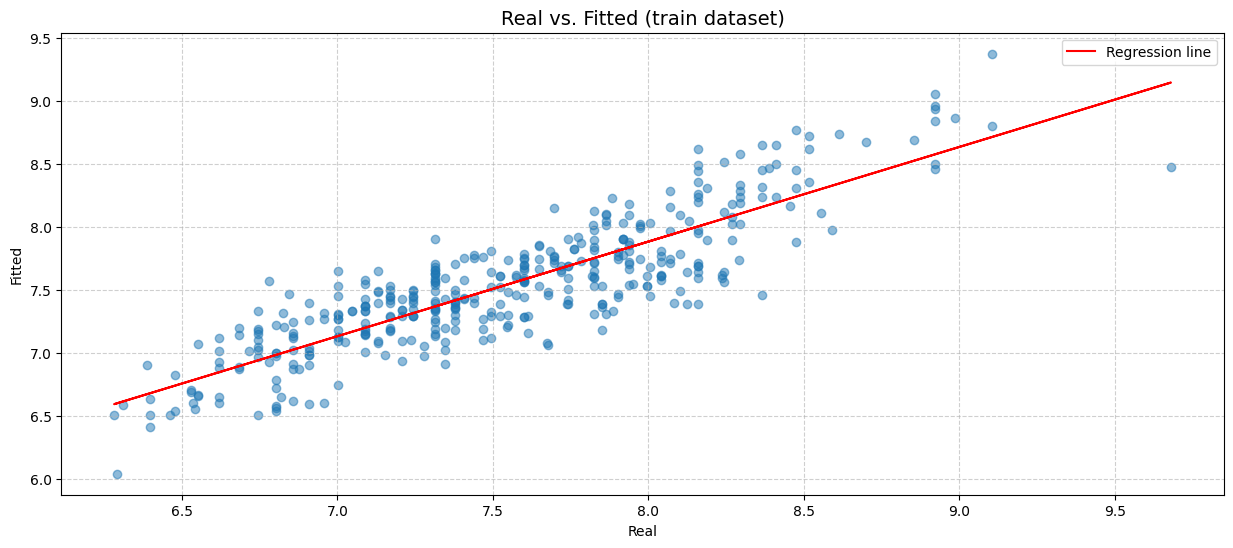

In [77]:
X_train_final_const = sm.add_constant(X_final)
y_pred = final_model.predict(X_train_final_const)
pred_chart(y_pred, y_train)

and now for the **test dataset**

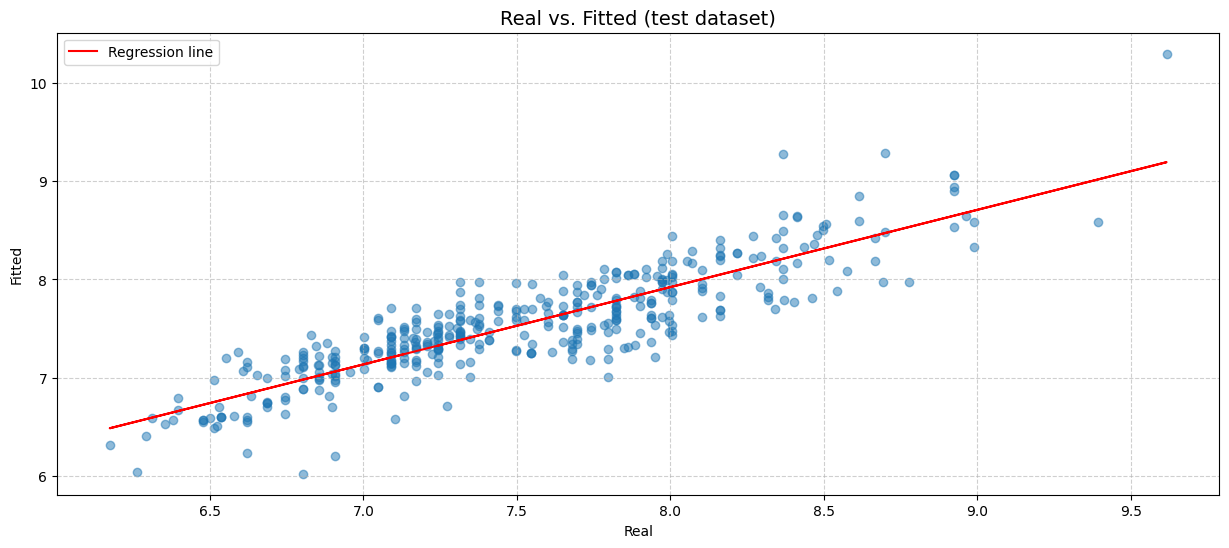

In [78]:
X_test_final_const = sm.add_constant(X_test[X_final.columns])
y_predtest = final_model.predict(X_test_final_const)
pred_chart(y_predtest, y_test, "test")

## 7. Histograms of residuals

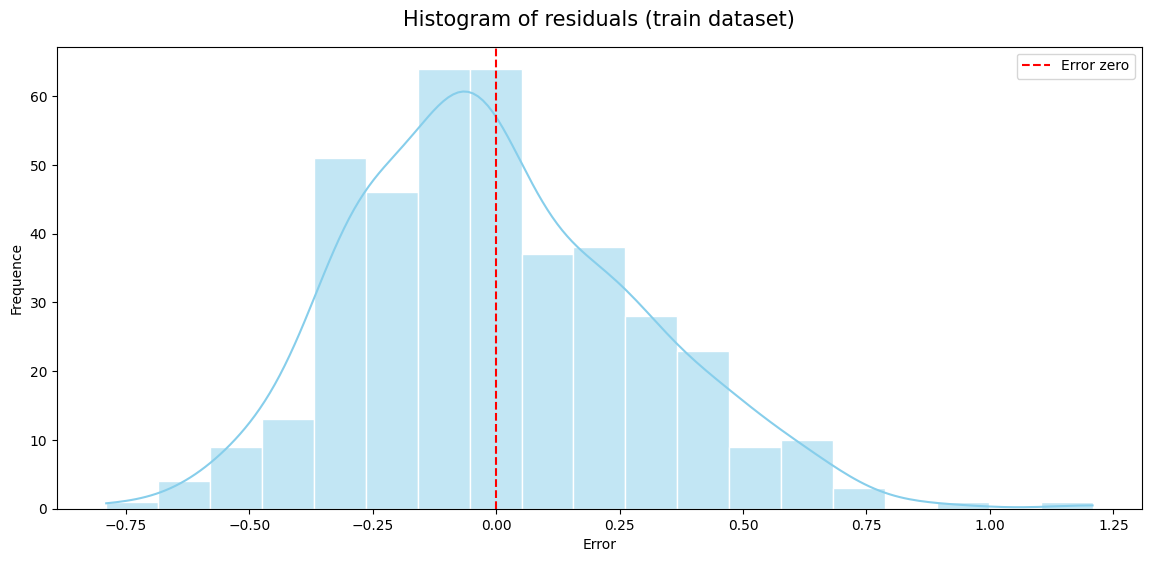

In [79]:
def Hist_resid(y, y_pred, dataset="train"):
    errors = y - y_pred
    plt.figure(figsize=(14, 6))
    sns.histplot(errors, kde=True, color="skyblue", edgecolor="white")
    plt.title(f"Histogram of residuals ({dataset} dataset)", fontsize=15, pad=15)
    plt.xlabel("Error")
    plt.ylabel("Frequence")
    plt.axvline(x=0, color='red', linestyle='--', label='Error zero')
    plt.legend()
    plt.show()

Hist_resid(y_train, y_pred)

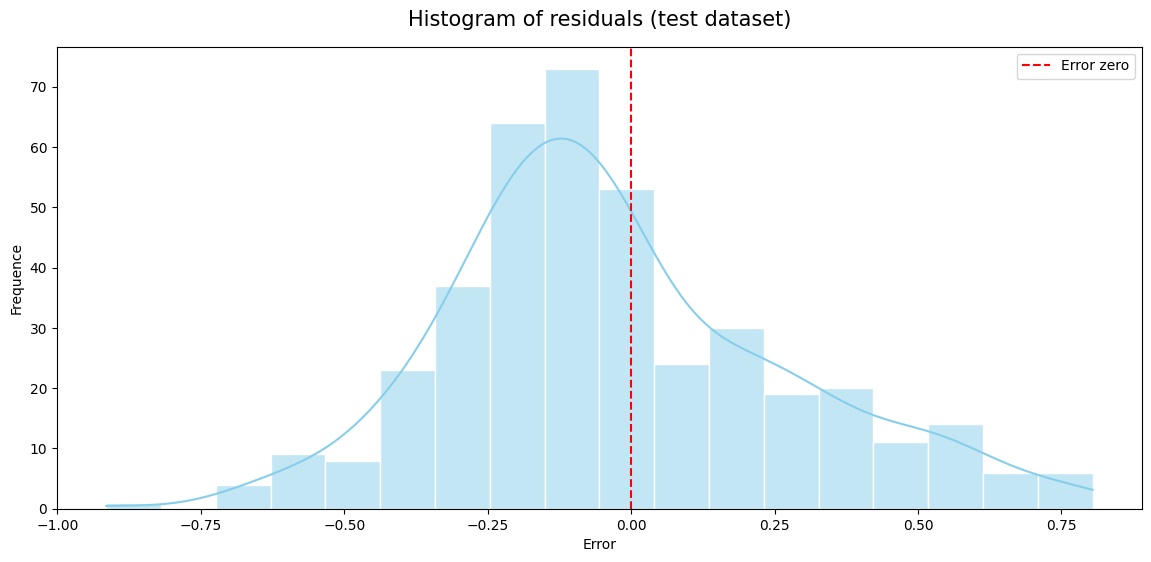

In [80]:
Hist_resid(y_test, y_predtest, "test")

We can see, according to our errors, that our model potentially overestimates rent prices just a bit

## 8. Regression Evaluation Metrics

Comparing these metrics:

- **MAE** is the easiest to understand, because it's the average error.
- **MSE** is more popular than MAE, because MSE "punishes" larger errors, which tends to be useful in the real world.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.
- **MAPE** is the best metric, because allows comparison between different models.

All of these are **loss functions**, because we want to minimize them.

In [82]:
from sklearn import metrics

# error comparison between the two datasets
results = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE %'],
    'Train': [
        metrics.mean_absolute_error(y_train, y_pred),
        metrics.mean_squared_error(y_train, y_pred),
        np.sqrt(metrics.mean_squared_error(y_train, y_pred)),
        np.mean(100 * abs(y_train - y_pred) / y_train)
    ],
    'Test': [
        metrics.mean_absolute_error(y_test, y_predtest),
        metrics.mean_squared_error(y_test, y_predtest),
        np.sqrt(metrics.mean_squared_error(y_test, y_predtest)),
        np.mean(100 * abs(y_test - y_predtest) / y_test)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Metric,Train,Test
0,MAE,0.231226,0.236922
1,MSE,0.085183,0.088898
2,RMSE,0.291862,0.298157
3,MAPE %,3.072203,3.150708
